In [1]:
!pip install ase

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 10.6 MB/s eta 0:00:00


In [2]:
# Check whether PySCF is already installed.
# If not, install it.

import importlib.util
import subprocess
import sys

if importlib.util.find_spec("pyscf") is None:
    print("PySCF not found. Installing...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "pyscf"
    ])
    print("PySCF installation completed.")
else:
    print("PySCF is already installed.")

PySCF not found. Installing...
PySCF installation completed.


In [3]:
# ============================================================
# D3BJ BACKEND RECOVERY
# ============================================================

import sys
import subprocess
import importlib

print("=" * 70)
print("CHECKING PYS CF D3BJ BACKEND")
print("=" * 70)

# 1. Install/reinstall the required dispersion package
subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "--upgrade",
    "pyscf-dispersion"
])

print("\npyscf-dispersion installation completed.")

# 2. Reload PySCF dispersion modules
import pyscf
import pyscf.dispersion.dftd3
import pyscf.scf.dispersion as scf_dispersion

scf_dispersion = importlib.reload(scf_dispersion)

print("PySCF version:", pyscf.__version__)
print("dftd3 object :", scf_dispersion.dftd3)
print("dftd4 object :", scf_dispersion.dftd4)

assert scf_dispersion.dftd3 is not None, (
    "D3BJ backend is still unavailable."
)

print("\n" + "=" * 70)
print("D3BJ BACKEND IS AVAILABLE")
print("=" * 70)

CHECKING PYS CF D3BJ BACKEND

pyscf-dispersion installation completed.
PySCF version: 2.14.0
dftd3 object : <module 'pyscf.dispersion.dftd3' from '/usr/local/lib/python3.13/dist-packages/pyscf/dispersion/dftd3.py'>
dftd4 object : <module 'pyscf.dispersion.dftd4' from '/usr/local/lib/python3.13/dist-packages/pyscf/dispersion/dftd4.py'>

D3BJ BACKEND IS AVAILABLE


In [4]:
# ============================================================
# CELL 04-INIT — RESTART-SAFE DFT ENVIRONMENT
# ============================================================
#
# Run this cell after every Colab runtime restart/reconnect.
#
# It:
#   1. Mounts Google Drive
#   2. Reconstructs project paths
#   3. Loads the CURRENT 563-configuration manifest
#   4. Reconstructs DFT directories
#   5. Checks PySCF + D3BJ
#   6. Restores run_pyscf_dft_job()
#
# It does NOT run the DFT dataset.
# It does NOT delete existing results.
# It does NOT rerun completed calculations.
# ============================================================

print("=" * 70)
print("ENERGYMOL-MLIP — RESTART-SAFE DFT INITIALIZATION")
print("=" * 70)


# ============================================================
# 1. GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=False
)

print("Google Drive mounted.")


# ============================================================
# 2. IMPORTS
# ============================================================

import sys
import json
import time
import importlib
from pathlib import Path

import numpy as np
import pandas as pd

from ase.io import read
from ase.units import Hartree, Bohr

from pyscf import gto, dft
import pyscf


# ============================================================
# 3. PROJECT PATHS
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/MLIP project"
)

DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

CONFIGS_DIR = PROJECT_DIR / "configs"

RESULTS_DIR = PROJECT_DIR / "results"
METRICS_DIR = RESULTS_DIR / "metrics"
FIGURES_DIR = RESULTS_DIR / "figures"

DFT_DIR = PROJECT_DIR / "dft"

DFT_INPUT_DIR = DFT_DIR / "inputs"
DFT_OUTPUT_DIR = DFT_DIR / "outputs"
DFT_FAILED_DIR = DFT_DIR / "failed"
DFT_PARSED_DIR = DFT_DIR / "parsed"


# Create directories if needed

for directory in [
    DFT_DIR,
    DFT_INPUT_DIR,
    DFT_OUTPUT_DIR,
    DFT_FAILED_DIR,
    DFT_PARSED_DIR,
    RESULTS_DIR,
    METRICS_DIR,
    FIGURES_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )


print("\nProject directory:")
print(PROJECT_DIR)


# ============================================================
# 4. LOAD CURRENT CONFIGURATION MANIFEST
# ============================================================

MANIFEST_FILE = (
    PROCESSED_DIR /
    "configuration_manifest.csv"
)

if not MANIFEST_FILE.exists():

    raise FileNotFoundError(
        f"\nCurrent configuration manifest was not found:\n"
        f"{MANIFEST_FILE}\n\n"
        f"Please run Notebook 03 first."
    )


manifest = pd.read_csv(
    MANIFEST_FILE
)


# ============================================================
# 5. VALIDATE CURRENT DATASET
# ============================================================

print("\n" + "=" * 70)
print("CURRENT CONFIGURATION MANIFEST")
print("=" * 70)

print("Manifest :", MANIFEST_FILE)
print("Rows     :", len(manifest))
print("Columns  :", len(manifest.columns))


assert len(manifest) == 563, (
    f"Expected 563 configurations, "
    f"found {len(manifest)}"
)

assert manifest[
    "configuration_id"
].is_unique, (
    "configuration_id values are not unique."
)

assert manifest[
    "molecule_id"
].nunique() == 24, (
    "Expected 24 molecules."
)

assert manifest[
    "family"
].nunique() == 6, (
    "Expected 6 chemical families."
)


print("Configurations :", len(manifest))
print("Molecules      :", manifest["molecule_id"].nunique())
print("Families       :", manifest["family"].nunique())

print("\nCURRENT MANIFEST VALIDATED.")


# ============================================================
# 6. D3BJ BACKEND
# ============================================================

print("\n" + "=" * 70)
print("CHECKING PySCF / D3BJ")
print("=" * 70)

print("PySCF version:", pyscf.__version__)


# Important after Colab reconnect/restart

try:

    import pyscf.dispersion.dftd3

    import pyscf.scf.dispersion as scf_dispersion

    scf_dispersion = importlib.reload(
        scf_dispersion
    )

except Exception as exc:

    raise RuntimeError(
        "Could not load the PySCF D3 dispersion backend.\n"
        f"Error: {exc}"
    )


print(
    "D3BJ backend:",
    scf_dispersion.dftd3
)

print(
    "D3D4 backend:",
    scf_dispersion.dftd4
)

if scf_dispersion.dftd3 is None:

    raise RuntimeError(
        "\nD3BJ backend is unavailable.\n"
        "Run the pyscf-dispersion installation/recovery cell."
    )

print("\nD3BJ backend is AVAILABLE.")


# ============================================================
# 7. UNIT CONVERSIONS
# ============================================================

HARTREE_TO_EV = Hartree

HARTREE_BOHR_TO_EV_A = (
    Hartree / Bohr
)


# ============================================================
# 8. RESTORE DFT FUNCTION
# ============================================================

def run_pyscf_dft_job(
    xyz_file,
    output_file,
    method="PBE0",
    dispersion="D3BJ",
    basis="def2-SVP",
    charge=0,
    spin=0
):

    xyz_file = Path(xyz_file)
    output_file = Path(output_file)

    start_time = time.time()

    # --------------------------------------------------------
    # READ XYZ
    # --------------------------------------------------------

    atoms = read(
        str(xyz_file)
    )

    atom_data = [
        (
            symbol,
            tuple(
                float(x)
                for x in position
            )
        )
        for symbol, position in zip(
            atoms.get_chemical_symbols(),
            atoms.get_positions()
        )
    ]

    # --------------------------------------------------------
    # BUILD PySCF MOLECULE
    # --------------------------------------------------------

    mol = gto.M(
        atom=atom_data,
        basis=basis,
        charge=charge,
        spin=spin,
        unit="Angstrom",
        verbose=0
    )

    # --------------------------------------------------------
    # PBE0-D3(BJ)
    # --------------------------------------------------------

    mf = dft.RKS(mol)

    mf.xc = "pbe0-d3bj"

    mf.conv_tol = 1e-9
    mf.conv_tol_grad = 1e-6
    mf.max_cycle = 150

    # --------------------------------------------------------
    # SCF
    # --------------------------------------------------------

    energy_hartree = mf.kernel()

    if not mf.converged:

        raise RuntimeError(
            "SCF failed to converge."
        )

    # --------------------------------------------------------
    # ANALYTIC GRADIENT
    # --------------------------------------------------------

    grad_method = (
        mf.nuc_grad_method()
    )

    gradient_hartree_bohr = (
        grad_method.kernel()
    )

    # --------------------------------------------------------
    # VALIDATE GRADIENT
    # --------------------------------------------------------

    expected_shape = (
        mol.natm,
        3
    )

    if gradient_hartree_bohr.shape != expected_shape:

        raise RuntimeError(
            f"Unexpected gradient shape: "
            f"{gradient_hartree_bohr.shape}; "
            f"expected {expected_shape}"
        )

    if not np.all(
        np.isfinite(
            gradient_hartree_bohr
        )
    ):

        raise RuntimeError(
            "Gradient contains non-finite values."
        )

    # --------------------------------------------------------
    # ENERGY CONVERSION
    # --------------------------------------------------------

    energy_eV = (
        energy_hartree *
        HARTREE_TO_EV
    )

    # --------------------------------------------------------
    # FORCE CONVERSION
    # --------------------------------------------------------

    forces_eV_A = (
        -gradient_hartree_bohr *
        HARTREE_BOHR_TO_EV_A
    )

    # --------------------------------------------------------
    # RUNTIME
    # --------------------------------------------------------

    elapsed = (
        time.time() -
        start_time
    )

    # --------------------------------------------------------
    # RESULT
    # --------------------------------------------------------

    result = {

        "status": "success",

        "xyz_file":
            str(xyz_file),

        "n_atoms":
            int(mol.natm),

        "energy_hartree":
            float(energy_hartree),

        "energy_eV":
            float(energy_eV),

        "forces_eV_A":
            forces_eV_A.tolist(),

        "max_force_eV_A":
            float(
                np.max(
                    np.abs(
                        forces_eV_A
                    )
                )
            ),

        "scf_converged":
            bool(
                mf.converged
            ),

        "scf_cycles":
            int(
                getattr(
                    mf,
                    "cycles",
                    -1
                )
            ),

        "runtime_seconds":
            float(
                elapsed
            ),

        "method":
            method,

        "dispersion":
            dispersion,

        "basis":
            basis,

        "charge":
            charge,

        "spin":
            spin,

        "software":
            "PySCF"
    }

    # --------------------------------------------------------
    # SAVE
    # --------------------------------------------------------

    output_file.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    with open(
        output_file,
        "w"
    ) as f:

        json.dump(
            result,
            f,
            indent=2
        )

    return result


# ============================================================
# 9. FINAL ENVIRONMENT CHECK
# ============================================================

print("\n" + "=" * 70)
print("RESTART-SAFE ENVIRONMENT READY")
print("=" * 70)

print("Project       :", PROJECT_DIR)
print("Manifest rows :", len(manifest))
print("DFT output    :", DFT_OUTPUT_DIR)
print("PySCF         :", pyscf.__version__)
print("D3BJ          :", "AVAILABLE")
print(
    "DFT function  :",
    run_pyscf_dft_job
)

print("=" * 70)
print("READY FOR DFT BATCH")
print("=" * 70)

ENERGYMOL-MLIP — RESTART-SAFE DFT INITIALIZATION
Mounted at /content/drive
Google Drive mounted.

Project directory:
/content/drive/MyDrive/MLIP project

CURRENT CONFIGURATION MANIFEST
Manifest : /content/drive/MyDrive/MLIP project/data/processed/configuration_manifest.csv
Rows     : 563
Columns  : 15
Configurations : 563
Molecules      : 24
Families       : 6

CURRENT MANIFEST VALIDATED.

CHECKING PySCF / D3BJ
PySCF version: 2.14.0
D3BJ backend: <module 'pyscf.dispersion.dftd3' from '/usr/local/lib/python3.13/dist-packages/pyscf/dispersion/dftd3.py'>
D3D4 backend: <module 'pyscf.dispersion.dftd4' from '/usr/local/lib/python3.13/dist-packages/pyscf/dispersion/dftd4.py'>

D3BJ backend is AVAILABLE.

RESTART-SAFE ENVIRONMENT READY
Project       : /content/drive/MyDrive/MLIP project
Manifest rows : 563
DFT output    : /content/drive/MyDrive/MLIP project/dft/outputs
PySCF         : 2.14.0
D3BJ          : AVAILABLE
DFT function  : <function run_pyscf_dft_job at 0x7dab1caca700>
READY FOR DFT

In [ ]:
import os
import sys
import json
import time
import shutil
import traceback
import warnings

from pathlib import Path

import numpy as np
import pandas as pd

from ase import Atoms
from ase.io import read, write

import pyscf
from pyscf import gto, dft

warnings.filterwarnings("ignore")

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("PySCF:", pyscf.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
NumPy: 2.1.3
Pandas: 2.2.3
PySCF: 2.14.0


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")

# Existing directories
DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

PILOT_STRUCTURES_DIR = PROJECT_DIR / "pilot_structures"
CONFIGS_DIR = PROJECT_DIR / "configs"

# New DFT directories
DFT_DIR = PROJECT_DIR / "dft"
DFT_INPUT_DIR = DFT_DIR / "inputs"
DFT_OUTPUT_DIR = DFT_DIR / "outputs"
DFT_FAILED_DIR = DFT_DIR / "failed"
DFT_PARSED_DIR = DFT_DIR / "parsed"

# Results
RESULTS_DIR = PROJECT_DIR / "results"
METRICS_DIR = RESULTS_DIR / "metrics"
FIGURES_DIR = RESULTS_DIR / "figures"

for directory in [
    DFT_DIR,
    DFT_INPUT_DIR,
    DFT_OUTPUT_DIR,
    DFT_FAILED_DIR,
    DFT_PARSED_DIR,
    METRICS_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project directory:")
print(PROJECT_DIR)

print("\nNotebook 04 directories created.")
print("=" * 70)
print("PySCF ENVIRONMENT CHECK")
print("=" * 70)

print(f"PySCF version: {pyscf.__version__}")

try:
    import pyscf.grad
    print("Gradient module: available")
except Exception as e:
    print("Gradient module problem:", e)

print("\nEnvironment check completed.")

Project directory:
/content/drive/MyDrive/MLIP project

Notebook 04 directories created.
PySCF ENVIRONMENT CHECK
PySCF version: 2.14.0
Gradient module: available

Environment check completed.


In [ ]:
MANIFEST_FILE = PROCESSED_DIR / "configuration_manifest.csv"

if not MANIFEST_FILE.exists():
    raise FileNotFoundError(
        f"Configuration manifest not found:\n{MANIFEST_FILE}"
    )

config_df = pd.read_csv(MANIFEST_FILE)

print("=" * 70)
print("CONFIGURATION MANIFEST")
print("=" * 70)

print("Rows:", len(config_df))
print("Columns:")
print(config_df.columns.tolist())

display(config_df.head())

CONFIGURATION MANIFEST
Rows: 563
Columns:
['molecule_id', 'molecule_name', 'family', 'configuration_id', 'xyz_path', 'source_type', 'parent_conformer', 'perturbation_sigma_A', 'rmsd_from_parent_A', 'max_atom_displacement_A', 'mean_atom_displacement_A', 'n_atoms', 'n_heavy_atoms', 'finite_coordinates', 'minimum_distance_A']


,molecule_id,molecule_name,family,configuration_id,xyz_path,source_type,parent_conformer,perturbation_sigma_A,rmsd_from_parent_A,max_atom_displacement_A,mean_atom_displacement_A,n_atoms,n_heavy_atoms,finite_coordinates,minimum_distance_A
0,M01,benzene,aromatic_hydrocarbon,M01_C001,/content/drive/MyDrive/MLIP project/configs/M0...,mmff_conformer,0,0.000,1.510704e-16,0.000000,0.000000,12,6,True,1.086729
1,M01,benzene,aromatic_hydrocarbon,M01_C002,/content/drive/MyDrive/MLIP project/configs/M0...,perturbed,0,0.125,5.021607e-02,0.201182,0.117055,12,6,True,1.033968
2,M01,benzene,aromatic_hydrocarbon,M01_C003,/content/drive/MyDrive/MLIP project/configs/M0...,perturbed,0,0.125,5.010017e-02,0.287937,0.102942,12,6,True,1.074630
3,M01,benzene,aromatic_hydrocarbon,M01_C004,/content/drive/MyDrive/MLIP project/configs/M0...,perturbed,0,0.125,5.349264e-02,0.184807,0.111621,12,6,True,1.000970
4,M01,benzene,aromatic_hydrocarbon,M01_C005,/content/drive/MyDrive/MLIP project/configs/M0...,perturbed,0,0.125,5.143661e-02,0.215258,0.113172,12,6,True,1.021333


In [ ]:
required_columns = [
    "configuration_id",
    "molecule_id",
    "molecule_name",
]

missing_columns = [
    col for col in required_columns
    if col not in config_df.columns
]

if missing_columns:
    raise ValueError(
        f"Required columns missing from configuration manifest: "
        f"{missing_columns}"
    )

print("Required manifest columns found.")
def locate_xyz_file(row):
    """
    Locate the XYZ file associated with one configuration.
    """

    possible_paths = []

    # If manifest contains an explicit path
    for col in ["xyz_path", "configuration_file", "file_path"]:
        if col in row.index and pd.notna(row[col]):
            possible_paths.append(Path(str(row[col])))

    # Search under configs if explicit path is absent
    config_id = str(row["configuration_id"])
    molecule_id = str(row["molecule_id"])
    molecule_name = str(row["molecule_name"])

    possible_paths.extend([
        CONFIGS_DIR / molecule_id / f"{config_id}.xyz",
        CONFIGS_DIR / molecule_name / f"{config_id}.xyz",
    ])

    for path in possible_paths:
        if path.exists():
            return path

    # Recursive fallback search
    matches = list(CONFIGS_DIR.rglob(f"{config_id}.xyz"))

    if matches:
        return matches[0]

    return None

Required manifest columns found.


In [ ]:
xyz_paths = []

for _, row in config_df.iterrows():
    path = locate_xyz_file(row)
    xyz_paths.append(path)

config_df["xyz_path"] = [
    str(p) if p is not None else ""
    for p in xyz_paths
]

missing_xyz = config_df[
    config_df["xyz_path"].str.len() == 0
]

print("=" * 70)
print("XYZ FILE VALIDATION")
print("=" * 70)

print("Configurations:", len(config_df))
print("XYZ files found:", len(config_df) - len(missing_xyz))
print("XYZ files missing:", len(missing_xyz))

if len(missing_xyz) > 0:
    display(missing_xyz.head(20))
    raise FileNotFoundError(
        f"{len(missing_xyz)} configuration XYZ files could not be found."
    )

print("\nALL 576 XYZ FILES FOUND.")

XYZ FILE VALIDATION
Configurations: 563
XYZ files found: 563
XYZ files missing: 0

ALL 576 XYZ FILES FOUND.


In [ ]:
DFT_PROTOCOL = {
    "method": "PBE0",
    "dispersion": "D3BJ",
    "basis": "def2-SVP",
    "charge": 0,
    "multiplicity": 1,
    "spin": 0,
    "solvent": None,
    "calculation": "single_point_energy_gradient",
    "geometry_optimization": False,
    "temperature_K": None,
    "software": "PySCF",
}

print(json.dumps(DFT_PROTOCOL, indent=4))

{
    "method": "PBE0",
    "dispersion": "D3BJ",
    "basis": "def2-SVP",
    "charge": 0,
    "multiplicity": 1,
    "spin": 0,
    "solvent": null,
    "calculation": "single_point_energy_gradient",
    "geometry_optimization": false,
    "temperature_K": null,
    "software": "PySCF"
}


In [ ]:
PROTOCOL_FILE = CONFIGS_DIR / "dft_protocol.json"

with open(PROTOCOL_FILE, "w") as f:
    json.dump(DFT_PROTOCOL, f, indent=4)

print(f"\nDFT protocol saved to:\n{PROTOCOL_FILE}")


DFT protocol saved to:
/content/drive/MyDrive/MLIP project/configs/dft_protocol.json


In [ ]:
# ============================================================
# CELL 10 — PYSCF DISPERSION CAPABILITY DIAGNOSTIC
# ============================================================

import importlib.util
import pkgutil
import pyscf

print("=" * 70)
print("PYSCF DISPERSION CAPABILITY DIAGNOSTIC")
print("=" * 70)

print("PySCF version:", pyscf.__version__)
print("PySCF location:", pyscf.__file__)

print("\nRelevant installed PySCF modules:")

pyscf_modules = sorted(
    module.name
    for module in pkgutil.iter_modules(pyscf.__path__)
    if any(
        key in module.name.lower()
        for key in ["dft", "grad", "disp", "gto"]
    )
)

for module in pyscf_modules:
    print("  ", module)

print("\nChecking possible external dispersion packages:")

packages_to_check = [
    "dftd3",
    "pyscf_dftd3",
    "tblite",
    "geometric",
    "ase",
]

for package in packages_to_check:
    available = importlib.util.find_spec(package) is not None
    print(f"  {package:15s}: {'available' if available else 'not found'}")

print("\nDiagnostic completed.")

PYSCF DISPERSION CAPABILITY DIAGNOSTIC
PySCF version: 2.14.0
PySCF location: /usr/local/lib/python3.13/dist-packages/pyscf/__init__.py

Relevant installed PySCF modules:
   dft
   dispersion
   grad
   gto
   mcpdft
   tddft

Checking possible external dispersion packages:
  dftd3          : not found
  pyscf_dftd3    : not found
  tblite         : not found
  geometric      : not found
  ase            : available

Diagnostic completed.


In [ ]:
# ============================================================
# CELL 10B — CHECK PYSCF DFT SUBMODULES
# ============================================================

from pyscf import dft

print("=" * 70)
print("PYSCF.DFT MODULE CONTENTS")
print("=" * 70)

names = sorted(
    name for name in dir(dft)
    if not name.startswith("_")
)

for name in names:
    print(name)

PYSCF.DFT MODULE CONTENTS
BRAGG_RADII
COVALENT_RADII
DFT
DKS
GKS
Grids
KS
KohnShamDFT
LebedevGrid
RDKS
RKS
RKSpU
ROKS
UDKS
UKS
UKSpU
X2C
X2C_KS
XC
becke_atomic_radii_adjust
delley
density_fit
dks
gauss_chebyshev
gen_grid
gks
gks_symm
grid
gto
libxc
mura_knowles
numint
numint2c
nwchem_prune
original_becke
r_numint
radi
rks
rks_symm
roks
sg1_prune
stratmann
treutler
treutler_ahlrichs
treutler_atomic_radii_adjust
treutler_prune
uks
uks_symm
xc
xc_deriv
xcfun


In [ ]:
# ============================================================
# CELL 10C — INSTALL PYSCF DISPERSION EXTENSION
# ============================================================

import subprocess
import sys

print("=" * 70)
print("INSTALLING PYSCF DISPERSION EXTENSION")
print("=" * 70)

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "pyscf-dispersion"
])

print("\nInstallation completed.")

INSTALLING PYSCF DISPERSION EXTENSION

Installation completed.


In [ ]:
# ============================================================
# CELL 10D — VERIFY D3 SUPPORT
# ============================================================

print("=" * 70)
print("VERIFYING PYSCF D3 SUPPORT")
print("=" * 70)

from pyscf import dispersion

print("PySCF dispersion module:", dispersion)

try:
    from pyscf.dispersion import dftd3
    print("DFTD3 backend: available")
except Exception as e:
    print("DFTD3 backend import failed:")
    print(repr(e))
    raise

print("\nD3 support is available.")

VERIFYING PYSCF D3 SUPPORT
PySCF dispersion module: <module 'pyscf.dispersion' from '/usr/local/lib/python3.13/dist-packages/pyscf/dispersion/__init__.py'>
DFTD3 backend: available

D3 support is available.


In [ ]:
# ============================================================
# CELL 10 — PYSCF DISPERSION CAPABILITY DIAGNOSTIC
# ============================================================

import importlib.util
import pkgutil
import pyscf

print("=" * 70)
print("PYSCF DISPERSION CAPABILITY DIAGNOSTIC")
print("=" * 70)

print("PySCF version:", pyscf.__version__)
print("PySCF location:", pyscf.__file__)

print("\nRelevant installed PySCF modules:")

pyscf_modules = sorted(
    module.name
    for module in pkgutil.iter_modules(pyscf.__path__)
    if any(
        key in module.name.lower()
        for key in ["dft", "grad", "disp", "gto"]
    )
)

for module in pyscf_modules:
    print("  ", module)

print("\nChecking possible external dispersion packages:")

packages_to_check = [
    "dftd3",
    "pyscf_dftd3",
    "tblite",
    "geometric",
    "ase",
]

for package in packages_to_check:
    available = importlib.util.find_spec(package) is not None
    print(f"  {package:15s}: {'available' if available else 'not found'}")

print("\nDiagnostic completed.")

PYSCF DISPERSION CAPABILITY DIAGNOSTIC
PySCF version: 2.14.0
PySCF location: /usr/local/lib/python3.13/dist-packages/pyscf/__init__.py

Relevant installed PySCF modules:
   dft
   dispersion
   grad
   gto
   mcpdft
   tddft

Checking possible external dispersion packages:
  dftd3          : not found
  pyscf_dftd3    : not found
  tblite         : not found
  geometric      : not found
  ase            : available

Diagnostic completed.


In [ ]:
# ============================================================
# CELL 10C — INSTALL PYSCF DISPERSION EXTENSION
# ============================================================

import subprocess
import sys

print("=" * 70)
print("INSTALLING PYSCF DISPERSION EXTENSION")
print("=" * 70)

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "pyscf-dispersion"
])

print("\nInstallation completed.")

INSTALLING PYSCF DISPERSION EXTENSION

Installation completed.


In [ ]:
# ============================================================
# CELL 10E — TEST PBE0-D3(BJ) PARSING
# ============================================================

from pyscf import scf

print("=" * 70)
print("PBE0-D3(BJ) PARSING TEST")
print("=" * 70)

xc_test = "pbe0-d3bj"

xc_base, nlc, disp_version = scf.dispersion.parse_dft(xc_test)

print("Input functional :", xc_test)
print("Base XC           :", xc_base)
print("NLC               :", nlc)
print("Dispersion        :", disp_version)

if xc_base.lower() != "pbe0":
    raise ValueError(
        f"Unexpected base functional: {xc_base}"
    )

if disp_version.lower() != "d3bj":
    raise ValueError(
        f"Unexpected dispersion method: {disp_version}"
    )

print("\nPBE0-D3(BJ) was recognized correctly.")

PBE0-D3(BJ) PARSING TEST
Input functional : pbe0-d3bj
Base XC           : pbe0
NLC               : 
Dispersion        : d3bj

PBE0-D3(BJ) was recognized correctly.


In [ ]:
from pyscf import scf

print("D3 backend loaded successfully.")
print("pyscf.scf.dispersion module:", scf.dispersion)

D3 backend loaded successfully.
pyscf.scf.dispersion module: <module 'pyscf.scf.dispersion' from '/usr/local/lib/python3.13/dist-packages/pyscf/scf/dispersion.py'>


In [ ]:
# ============================================================
# CELL 11 — PYSCF TEST SETUP
# ============================================================

import time
import numpy as np

from pathlib import Path

from ase import Atoms
from ase.io import read

from pyscf import gto, dft

print("=" * 70)
print("PYSCF TEST SETUP")
print("=" * 70)


def ase_to_pyscf_mol(
    atoms,
    charge=0,
    spin=0,
    basis="def2-SVP"
):
    """
    Convert an ASE Atoms object into a PySCF Mole object.

    Parameters
    ----------
    atoms : ASE Atoms
        Molecular structure with coordinates in Å.
    charge : int
        Molecular charge.
    spin : int
        N_alpha - N_beta.
        spin=0 corresponds to a closed-shell system.
    basis : str
        PySCF basis-set name.

    Returns
    -------
    pyscf.gto.Mole
    """

    atom_data = [
        (
            symbol,
            tuple(float(x) for x in position)
        )
        for symbol, position in zip(
            atoms.get_chemical_symbols(),
            atoms.get_positions()
        )
    ]

    mol = gto.M(
        atom=atom_data,
        basis=basis,
        charge=charge,
        spin=spin,
        unit="Angstrom",
        verbose=4
    )

    return mol


# ------------------------------------------------------------
# Select test configuration
# ------------------------------------------------------------

TEST_CONFIG_ID = "M01_C001"

test_row = config_df[
    config_df["configuration_id"] == TEST_CONFIG_ID
]

if len(test_row) != 1:
    raise ValueError(
        f"Expected exactly one row for {TEST_CONFIG_ID}, "
        f"found {len(test_row)}"
    )

test_row = test_row.iloc[0]

TEST_XYZ = Path(test_row["xyz_path"])

if not TEST_XYZ.exists():
    raise FileNotFoundError(
        f"XYZ file not found:\n{TEST_XYZ}"
    )


# ------------------------------------------------------------
# Read structure
# ------------------------------------------------------------

test_atoms = read(TEST_XYZ)

print("Configuration ID :", TEST_CONFIG_ID)
print("Molecule          :", test_row["molecule_name"])
print("Family            :", test_row["family"])
print("Formula            :", test_atoms.get_chemical_formula())
print("Number of atoms   :", len(test_atoms))
print("XYZ file          :", TEST_XYZ)


# ------------------------------------------------------------
# Build PySCF molecule
# ------------------------------------------------------------

test_mol = ase_to_pyscf_mol(
    test_atoms,
    charge=DFT_PROTOCOL["charge"],
    spin=DFT_PROTOCOL["spin"],
    basis=DFT_PROTOCOL["basis"]
)

print("\nPySCF molecule created successfully.")
print("PySCF atoms       :", test_mol.natm)
print("Electrons         :", test_mol.nelectron)
print("Charge            :", test_mol.charge)
print("Spin              :", test_mol.spin)
print("Basis             :", DFT_PROTOCOL["basis"])

print("\nCell 11 completed successfully.")

PYSCF TEST SETUP
Configuration ID : M01_C001
Molecule          : benzene
Family            : aromatic_hydrocarbon
Formula            : C6H6
Number of atoms   : 12
XYZ file          : /content/drive/MyDrive/MLIP project/configs/M01_benzene/M01_C001.xyz
System: uname_result(system='Linux', node='b7c6c94d57cf', release='6.6.122+', version='#1 SMP Thu Apr 30 18:17:14 UTC 2026', machine='x86_64')  Threads 2
Python 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
numpy 2.1.3  scipy 1.16.3  h5py 3.16.0
Date: Wed Sep 30 06:52:46 2026
PySCF version 2.14.0
PySCF path  /usr/local/lib/python3.13/dist-packages/pyscf

[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 12
[INPUT] num. electrons = 42
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry False subgroup None
[INPUT] Mole.unit = Angstrom
[INPUT] Symbol           X                Y                Z      unit          X                Y                Z       unit  Magmom
[INPUT]  1 C     -0.8875285

In [ ]:
import sys

!{sys.executable} -m pip install pyscf-dispersion

In [ ]:
# ============================================================
# FIX: RELOAD PYSCF DISPERSION BACKEND
# ============================================================

import importlib
import pyscf.dispersion.dftd3

# Reload the SCF dispersion module after D3 is available
import pyscf.scf.dispersion as scf_dispersion
scf_dispersion = importlib.reload(scf_dispersion)

print("=" * 70)
print("D3 BACKEND RELOAD TEST")
print("=" * 70)

print("dftd3 =", scf_dispersion.dftd3)
print("dftd4 =", scf_dispersion.dftd4)

if scf_dispersion.dftd3 is None:
    raise RuntimeError("D3 backend is STILL unavailable.")

print()
print("SUCCESS: PySCF SCF module can now access DFTD3.")

D3 BACKEND RELOAD TEST
dftd3 = <module 'pyscf.dispersion.dftd3' from '/usr/local/lib/python3.13/dist-packages/pyscf/dispersion/dftd3.py'>
dftd4 = <module 'pyscf.dispersion.dftd4' from '/usr/local/lib/python3.13/dist-packages/pyscf/dispersion/dftd4.py'>

SUCCESS: PySCF SCF module can now access DFTD3.


In [ ]:
# ============================================================
# CELL 12 — PBE0-D3(BJ)/def2-SVP SCF TEST
# ============================================================

import time
import numpy as np
from pyscf import dft

print("=" * 70)
print("PBE0-D3(BJ)/def2-SVP SCF TEST")
print("=" * 70)

print("Functional :", "pbe0-d3bj")
print("Basis      :", test_mol.basis)
print("Charge     :", test_mol.charge)
print("Spin       :", test_mol.spin)

# ------------------------------------------------------------
# Build RKS calculation
# ------------------------------------------------------------

mf_test = dft.RKS(test_mol)
mf_test.xc = "pbe0-d3bj"

mf_test.conv_tol = 1e-9
mf_test.conv_tol_grad = 1e-6
mf_test.max_cycle = 150

# ------------------------------------------------------------
# Run SCF
# ------------------------------------------------------------

start_time = time.time()

energy_pbe0_d3bj_hartree = mf_test.kernel()

elapsed = time.time() - start_time

print()
print("=" * 70)
print("SCF RESULT")
print("=" * 70)

print("Converged :", mf_test.converged)
print(f"Energy    : {energy_pbe0_d3bj_hartree:.12f} Hartree")
print(f"Time      : {elapsed:.2f} seconds")

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

if not mf_test.converged:
    raise RuntimeError("PBE0-D3(BJ) SCF did not converge.")

if not np.isfinite(energy_pbe0_d3bj_hartree):
    raise RuntimeError("PBE0-D3(BJ) energy is not finite.")

print()
print("SCF ENERGY TEST PASSED.")

PBE0-D3(BJ)/def2-SVP SCF TEST
Functional : pbe0-d3bj
Basis      : def2-SVP
Charge     : 0
Spin       : 0


******** <class 'pyscf.dft.rks.RKS'> ********
method = RKS
initial guess = minao
damping factor = 0
level_shift factor = 0
DIIS = <class 'pyscf.scf.diis.CDIIS'>
diis_start_cycle = 1
diis_space = 8
diis_damp = 0
SCF conv_tol = 1e-09
SCF conv_tol_grad = 1e-06
SCF max_cycles = 150
direct_scf = True
direct_scf_tol = 1e-13
chkfile to save SCF result = /tmp/tmp6mb5b8dc
max_memory 4000 MB (current use 272 MB)
XC library pyscf.dft.libxc version 7.0.0
    S. Lehtola, C. Steigemann, M. J.T. Oliveira, and M. A.L. Marques.,  SoftwareX 7, 1–5 (2018)
XC functionals = pbe0-d3bj
    C. Adamo and V. Barone.,  J. Chem. Phys. 110, 6158 (1999)
    M. Ernzerhof and G. E. Scuseria.,  J. Chem. Phys. 110, 5029 (1999)
radial grids: 
Treutler-Ahlrichs [JCP 102, 346 (1995); DOI:10.1063/1.469408] (M4) radial grids

becke partition: Becke, JCP 88, 2547 (1988); DOI:10.1063/1.454033
pruning grids: <function nwc

In [ ]:
# ============================================================
# CELL 14 — PBE0-D3(BJ) NUCLEAR GRADIENT TEST
# ============================================================

import numpy as np

print("=" * 70)
print("PBE0-D3(BJ)/def2-SVP GRADIENT TEST")
print("=" * 70)

# Obtain nuclear gradient
grad_method = mf_test.nuc_grad_method()

total_gradient_hartree_bohr = grad_method.kernel()

print()
print("Gradient shape:", total_gradient_hartree_bohr.shape)
print("Expected shape:", (test_mol.natm, 3))

print()
print("Gradient statistics")
print("-" * 70)
print(
    f"Minimum : {np.min(total_gradient_hartree_bohr): .8e} Hartree/Bohr"
)
print(
    f"Maximum : {np.max(total_gradient_hartree_bohr): .8e} Hartree/Bohr"
)
print(
    f"Max abs : {np.max(np.abs(total_gradient_hartree_bohr)): .8e} Hartree/Bohr"
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

if total_gradient_hartree_bohr.shape != (test_mol.natm, 3):
    raise RuntimeError(
        f"Unexpected gradient shape: "
        f"{total_gradient_hartree_bohr.shape}"
    )

if not np.all(np.isfinite(total_gradient_hartree_bohr)):
    raise RuntimeError(
        "Gradient contains NaN or infinite values."
    )

print()
print("GRADIENT CALCULATION PASSED.")

PBE0-D3(BJ)/def2-SVP GRADIENT TEST


******** <class 'pyscf.grad.rks.Gradients'> for <class 'pyscf.dft.rks.RKS'> ********
unit = Eh/Bohr
max_memory 4000 MB (current use 470 MB)
grid_response = False
Calc dispersion correction with DFTD3.
Parameters: xc=pbe0, version=d3bj, atm=False
--------------- RKS gradients ---------------
         x                y                z
0 C    -0.0027511667    -0.0033364185    -0.0000456221
1 C    -0.0042778794     0.0007208504     0.0001403818
2 C    -0.0015045153     0.0040442093     0.0001965545
3 C     0.0027505300     0.0033361220     0.0000462687
4 C     0.0042783381    -0.0007209041    -0.0001406056
5 C     0.0015041659    -0.0040438216    -0.0001961247
6 H     0.0027210911     0.0032987209     0.0000482454
7 H     0.0042153489    -0.0007033917    -0.0001428143
8 H     0.0014948947    -0.0040019021    -0.0001907142
9 H    -0.0027213905    -0.0032979424    -0.0000482239
10 H    -0.0042149701     0.0007029157     0.0001424947
11 H    -0.001494446

In [ ]:
# ============================================================
# CELL 15 — ENERGY AND FORCE UNIT CONVERSION
# ============================================================

import numpy as np
from ase.units import Hartree, Bohr

print("=" * 70)
print("DFT ENERGY / FORCE UNIT CONVERSION")
print("=" * 70)

# ------------------------------------------------------------
# Energy
# Hartree -> eV
# ------------------------------------------------------------

energy_eV = energy_pbe0_d3bj_hartree * Hartree

# ------------------------------------------------------------
# Gradient
# Hartree/Bohr -> eV/Angstrom
# ------------------------------------------------------------

gradient_to_eV_A = Hartree / Bohr

gradient_eV_A = total_gradient_hartree_bohr * gradient_to_eV_A

# Forces are negative gradient
forces_eV_A = -gradient_eV_A

# ------------------------------------------------------------
# Print
# ------------------------------------------------------------

print(f"Energy       : {energy_eV:.10f} eV")
print(
    f"Force range  : "
    f"{forces_eV_A.min():.8f} to {forces_eV_A.max():.8f} eV/Angstrom"
)
print(
    f"Max |force|  : "
    f"{np.max(np.abs(forces_eV_A)):.8f} eV/Angstrom"
)

print()
print("Force array shape:", forces_eV_A.shape)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

if forces_eV_A.shape != (test_mol.natm, 3):
    raise RuntimeError(
        f"Unexpected force shape: {forces_eV_A.shape}"
    )

if not np.all(np.isfinite(forces_eV_A)):
    raise RuntimeError(
        "Forces contain NaN or infinite values."
    )

print()
print("ENERGY/FORCE UNIT CONVERSION PASSED.")

DFT ENERGY / FORCE UNIT CONVERSION
Energy       : -6307.9071641120 eV
Force range  : -0.22000099 to 0.21997740 eV/Angstrom
Max |force|  : 0.22000099 eV/Angstrom

Force array shape: (12, 3)

ENERGY/FORCE UNIT CONVERSION PASSED.


In [ ]:
# ============================================================
# CELL 16 — SELECT 12-CONFIGURATION DFT PILOT
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

print("=" * 70)
print("DFT PILOT SELECTION")
print("=" * 70)

# ------------------------------------------------------------
# Load configuration manifest
# ------------------------------------------------------------

manifest = pd.read_csv(MANIFEST_FILE)

print("Manifest rows:", len(manifest))
print("Configuration ID example:")
print(manifest["configuration_id"].head().tolist())

# ------------------------------------------------------------
# Representative molecules
# ------------------------------------------------------------
#
# M01 : benzene
# M09 : 1,2,3-thiadiazole
# M16 : 2-(4-nitrophenyl)thiophene
# M20 : 2,3,5,6-tetrafluoropyridine
#
# Three configurations per molecule, evenly spaced across
# whatever range is actually available for that molecule:
# near-parent, intermediate, strongest perturbation.
# ------------------------------------------------------------

pilot_molecules = {
    "M01": "benzene",
    "M09": "1,2,3-thiadiazole",
    "M16": "2-(4-nitrophenyl)thiophene",
    "M20": "2,3,5,6-tetrafluoropyridine",
}

N_PER_MOLECULE = 3

# ------------------------------------------------------------
# Adaptive selection helper
# ------------------------------------------------------------

def select_pilot_configs(molecule_id, manifest, n_select=3):
    """
    Select n_select configurations spanning the available range for
    this molecule (first, ~middle, last), robust to molecules that
    have fewer than the nominal 24 configurations.
    """
    subset = manifest[
        manifest["molecule_id"] == molecule_id
    ].sort_values("configuration_id").reset_index(drop=True)

    n_available = len(subset)

    if n_available < n_select:
        raise RuntimeError(
            f"Only {n_available} configurations available for "
            f"{molecule_id}, need at least {n_select}."
        )

    indices = np.linspace(
        0, n_available - 1, n_select
    ).round().astype(int)

    indices = sorted(set(indices))

    return subset.iloc[indices]

# ------------------------------------------------------------
# Select configurations
# ------------------------------------------------------------

pilot_rows = []

for molecule_id, molecule_name in pilot_molecules.items():

    subset = select_pilot_configs(
        molecule_id,
        manifest,
        n_select=N_PER_MOLECULE,
    )

    if len(subset) < N_PER_MOLECULE:
        print()
        print("ERROR for:", molecule_id)
        print(f"Expected {N_PER_MOLECULE}, got {len(subset)}")

        available = manifest[
            manifest["molecule_id"] == molecule_id
        ]["configuration_id"].tolist()

        print("Available:", available[:10])

        raise RuntimeError(
            f"Expected {N_PER_MOLECULE} configurations for "
            f"{molecule_id}, found {len(subset)}."
        )

    pilot_rows.append(subset)

# ------------------------------------------------------------
# Combine
# ------------------------------------------------------------

pilot_manifest = pd.concat(
    pilot_rows,
    ignore_index=True
)

# ------------------------------------------------------------
# Sort reproducibly
# ------------------------------------------------------------

pilot_manifest = pilot_manifest.sort_values(
    ["molecule_id", "configuration_id"]
).reset_index(drop=True)

# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

expected_total = len(pilot_molecules) * N_PER_MOLECULE

if len(pilot_manifest) != expected_total:
    raise RuntimeError(
        f"Expected {expected_total} pilot configurations, "
        f"found {len(pilot_manifest)}."
    )

if pilot_manifest["molecule_id"].nunique() != len(pilot_molecules):
    raise RuntimeError(
        f"Pilot does not contain exactly {len(pilot_molecules)} molecules."
    )

counts = pilot_manifest.groupby(
    "molecule_id"
).size()

if not (counts == N_PER_MOLECULE).all():
    raise RuntimeError(
        f"Incorrect configurations per molecule:\n{counts}"
    )

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print()
print("=" * 70)
print("SELECTED PILOT CONFIGURATIONS")
print("=" * 70)

display(
    pilot_manifest[
        [
            "molecule_id",
            "molecule_name",
            "family",
            "configuration_id",
            "perturbation_sigma_A",
            "rmsd_from_parent_A",
            "max_atom_displacement_A",
            "xyz_path",
        ]
    ]
)

print()
print("=" * 70)
print("PILOT SUMMARY")
print("=" * 70)

print("Number of molecules :", pilot_manifest["molecule_id"].nunique())
print("Number of jobs      :", len(pilot_manifest))

print()
print("Configurations per molecule:")
print(counts)

print()
print("PILOT SELECTION PASSED.")

DFT PILOT SELECTION
Manifest rows: 563
Configuration ID example:
['M01_C001', 'M01_C002', 'M01_C003', 'M01_C004', 'M01_C005']

SELECTED PILOT CONFIGURATIONS


,molecule_id,molecule_name,family,configuration_id,perturbation_sigma_A,rmsd_from_parent_A,max_atom_displacement_A,xyz_path
0,M01,benzene,aromatic_hydrocarbon,M01_C001,0.000,1.510704e-16,0.000000,/content/drive/MyDrive/MLIP project/configs/M0...
1,M01,benzene,aromatic_hydrocarbon,M01_C012,0.100,5.171705e-02,0.131582,/content/drive/MyDrive/MLIP project/configs/M0...
2,M01,benzene,aromatic_hydrocarbon,M01_C023,0.125,5.686910e-02,0.220041,/content/drive/MyDrive/MLIP project/configs/M0...
3,M09,1_2_3_thiadiazole,S_heteroaromatic,M09_C001,0.000,1.383406e-16,0.000000,/content/drive/MyDrive/MLIP project/configs/M0...
4,M09,1_2_3_thiadiazole,S_heteroaromatic,M09_C013,0.125,5.681556e-02,0.171740,/content/drive/MyDrive/MLIP project/configs/M0...
5,M09,1_2_3_thiadiazole,S_heteroaromatic,M09_C024,0.125,5.961468e-02,0.192475,/content/drive/MyDrive/MLIP project/configs/M0...
6,M16,2_4_nitrophenyl_thiophene,donor_acceptor,M16_C001,0.000,7.625278e-16,0.000000,/content/drive/MyDrive/MLIP project/configs/M1...
7,M16,2_4_nitrophenyl_thiophene,donor_acceptor,M16_C013,0.125,5.248425e-02,0.281337,/content/drive/MyDrive/MLIP project/configs/M1...
8,M16,2_4_nitrophenyl_thiophene,donor_acceptor,M16_C024,0.100,5.100115e-02,0.174495,/content/drive/MyDrive/MLIP project/configs/M1...
9,M20,2_3_5_6_tetrafluoropyridine,fluorinated,M20_C001,0.000,2.144051e-16,0.000000,/content/drive/MyDrive/MLIP project/configs/M2...



PILOT SUMMARY
Number of molecules : 4
Number of jobs      : 12

Configurations per molecule:
molecule_id
M01    3
M09    3
M16    3
M20    3
dtype: int64

PILOT SELECTION PASSED.


In [ ]:
# ============================================================
# CELL 17 — CREATE DFT PILOT JOB DIRECTORIES
# ============================================================

from pathlib import Path
import json

print("=" * 70)
print("CREATING DFT PILOT JOB DIRECTORIES")
print("=" * 70)

# ------------------------------------------------------------
# Directory structure
# ------------------------------------------------------------

DFT_DIR.mkdir(parents=True, exist_ok=True)
DFT_INPUT_DIR.mkdir(parents=True, exist_ok=True)
DFT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DFT_FAILED_DIR.mkdir(parents=True, exist_ok=True)
DFT_PARSED_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Create one directory per configuration
# ------------------------------------------------------------

for _, row in pilot_manifest.iterrows():

    job_id = row["configuration_id"]
    molecule_id = row["molecule_id"]

    job_dir = DFT_INPUT_DIR / f"{molecule_id}_{job_id}"
    job_dir.mkdir(parents=True, exist_ok=True)

print(f"Created job directories: {len(pilot_manifest)}")

# ------------------------------------------------------------
# Save pilot manifest
# ------------------------------------------------------------

PILOT_MANIFEST_FILE = (
    PROCESSED_DIR / "dft_pilot_manifest.csv"
)

pilot_manifest.to_csv(
    PILOT_MANIFEST_FILE,
    index=False
)

print()
print("Pilot manifest:")
print(PILOT_MANIFEST_FILE)

print()
print("DFT PILOT DIRECTORIES READY.")

CREATING DFT PILOT JOB DIRECTORIES
Created job directories: 12

Pilot manifest:
/content/drive/MyDrive/MLIP project/data/processed/dft_pilot_manifest.csv

DFT PILOT DIRECTORIES READY.


In [ ]:
# ============================================================
# CELL 18 — RESTARTABLE PYSCF DFT LABELING FUNCTION
# ============================================================

import json
import time
import traceback
import numpy as np
from pathlib import Path

from ase.io import read
from ase.units import Hartree, Bohr

from pyscf import gto, dft

# ------------------------------------------------------------
# Unit conversion
# ------------------------------------------------------------

HARTREE_TO_EV = Hartree
HARTREE_BOHR_TO_EV_A = Hartree / Bohr

# ------------------------------------------------------------
# DFT calculation function
# ------------------------------------------------------------

def run_pyscf_dft_job(
    xyz_file,
    output_file,
    method="PBE0",
    dispersion="D3BJ",
    basis="def2-SVP",
    charge=0,
    spin=0,
):

    xyz_file = Path(xyz_file)
    output_file = Path(output_file)

    start_time = time.time()

    # --------------------------------------------------------
    # Read XYZ
    # --------------------------------------------------------

    atoms = read(str(xyz_file))

    atom_data = [
        (
            symbol,
            tuple(float(x) for x in position)
        )
        for symbol, position in zip(
            atoms.get_chemical_symbols(),
            atoms.get_positions()
        )
    ]

    # --------------------------------------------------------
    # Build PySCF molecule
    # --------------------------------------------------------

    mol = gto.M(
        atom=atom_data,
        basis=basis,
        charge=charge,
        spin=spin,
        unit="Angstrom",
        verbose=0,
    )

    # --------------------------------------------------------
    # RKS / PBE0-D3(BJ)
    # --------------------------------------------------------

    mf = dft.RKS(mol)

    mf.xc = "pbe0-d3bj"

    mf.conv_tol = 1e-9
    mf.conv_tol_grad = 1e-6
    mf.max_cycle = 150

    # --------------------------------------------------------
    # SCF
    # --------------------------------------------------------

    energy_hartree = mf.kernel()

    if not mf.converged:
        raise RuntimeError(
            "SCF failed to converge."
        )

    # --------------------------------------------------------
    # Nuclear gradient
    # --------------------------------------------------------

    grad_method = mf.nuc_grad_method()

    gradient_hartree_bohr = grad_method.kernel()

    if gradient_hartree_bohr.shape != (mol.natm, 3):
        raise RuntimeError(
            f"Unexpected gradient shape: "
            f"{gradient_hartree_bohr.shape}"
        )

    if not np.all(np.isfinite(gradient_hartree_bohr)):
        raise RuntimeError(
            "Gradient contains NaN or infinite values."
        )

    # --------------------------------------------------------
    # Convert units
    # --------------------------------------------------------

    energy_eV = energy_hartree * HARTREE_TO_EV

    # Force = -gradient
    forces_eV_A = (
        -gradient_hartree_bohr
        * HARTREE_BOHR_TO_EV_A
    )

    # --------------------------------------------------------
    # Runtime
    # --------------------------------------------------------

    elapsed = time.time() - start_time

    # --------------------------------------------------------
    # Result dictionary
    # --------------------------------------------------------

    result = {
        "status": "success",
        "xyz_file": str(xyz_file),

        "n_atoms": int(mol.natm),

        "energy_hartree": float(energy_hartree),
        "energy_eV": float(energy_eV),

        "forces_eV_A": forces_eV_A.tolist(),

        "max_force_eV_A": float(
            np.max(np.abs(forces_eV_A))
        ),

        "scf_converged": bool(mf.converged),

        "scf_cycles": int(
            getattr(mf, "cycles", -1)
        ),

        "runtime_seconds": float(elapsed),

        "method": method,
        "dispersion": dispersion,
        "basis": basis,
        "charge": charge,
        "spin": spin,
        "software": "PySCF",
    }

    # --------------------------------------------------------
    # Save JSON
    # --------------------------------------------------------

    output_file.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    with open(output_file, "w") as f:
        json.dump(
            result,
            f,
            indent=2
        )

    return result

In [ ]:
# ============================================================
# CELL 19 — RUN AND VALIDATE FIRST DFT PILOT JOB
# ============================================================

print("=" * 70)
print("RUNNING FIRST DFT PILOT JOB")
print("=" * 70)

first_job = pilot_manifest.iloc[0]

# configuration_id already contains the molecule ID
# Example: M01_C001
job_id = first_job["configuration_id"]

input_file = Path(first_job["xyz_path"])
output_file = DFT_OUTPUT_DIR / f"{job_id}.json"

print(f"Job ID : {job_id}")
print(f"Input  : {input_file}")
print(f"Output : {output_file}")

# Run calculation
result = run_pyscf_dft_job(
    xyz_file=input_file,
    output_file=output_file,
    method="PBE0",
    dispersion="D3BJ",
    basis="def2-SVP",
    charge=0,
    spin=0
)

print("\n" + "=" * 70)
print("RESULT")
print("=" * 70)

print(f"Status        : {result['status']}")
print(f"Energy        : {result['energy_eV']:.8f} eV")
print(f"Max |force|   : {result['max_force_eV_A']:.8f} eV/Å")
print(f"SCF converged : {result['scf_converged']}")
print(f"SCF cycles    : {result['scf_cycles']}")
print(f"Runtime       : {result['runtime_seconds']:.2f} s")

# Basic validation
assert result["status"] == "success"
assert result["scf_converged"] is True
assert np.isfinite(result["energy_eV"])
assert np.isfinite(result["max_force_eV_A"])

forces = np.array(result["forces_eV_A"])

assert forces.shape == (
    result["n_atoms"],
    3
)

assert np.all(np.isfinite(forces))

print("\nFIRST DFT JOB COMPLETED AND VALIDATED.")

RUNNING FIRST DFT PILOT JOB
Job ID : M01_C001
Input  : /content/drive/MyDrive/MLIP project/configs/M01_benzene/M01_C001.xyz
Output : /content/drive/MyDrive/MLIP project/dft/outputs/M01_C001.json

RESULT
Status        : success
Energy        : -6307.90716411 eV
Max |force|   : 0.22000099 eV/Å
SCF converged : True
SCF cycles    : 8
Runtime       : 38.96 s

FIRST DFT JOB COMPLETED AND VALIDATED.


In [ ]:
# ============================================================
# CELL 20 — RUN DFT PILOT BATCH
# ============================================================

import time
import json
import numpy as np
import pandas as pd
from pathlib import Path

print("=" * 70)
print("RUNNING DFT PILOT BATCH")
print("=" * 70)

pilot_results = []
successful = 0
failed = 0
skipped = 0

for i, row in pilot_manifest.iterrows():

    job_id = row["configuration_id"]

    input_file = Path(row["xyz_path"])
    output_file = DFT_OUTPUT_DIR / f"{job_id}.json"

    print("\n" + "-" * 70)
    print(f"[{i + 1}/{len(pilot_manifest)}] {job_id}")
    print(f"Molecule : {row['molecule_name']}")
    print(f"Family   : {row['family']}")
    print(f"Input    : {input_file}")
    print(f"Output   : {output_file}")

    # --------------------------------------------------------
    # Skip an already completed calculation
    # --------------------------------------------------------
    if output_file.exists():

        print("Status   : already completed — skipping")

        with open(output_file, "r") as f:
            result = json.load(f)

        result["configuration_id"] = job_id
        result["molecule_id"] = row["molecule_id"]
        result["molecule_name"] = row["molecule_name"]
        result["family"] = row["family"]

        pilot_results.append(result)
        skipped += 1

        continue

    # --------------------------------------------------------
    # Run DFT calculation
    # --------------------------------------------------------
    try:

        result = run_pyscf_dft_job(
            xyz_file=input_file,
            output_file=output_file,
            method="PBE0",
            dispersion="D3BJ",
            basis="def2-SVP",
            charge=0,
            spin=0
        )

        result["configuration_id"] = job_id
        result["molecule_id"] = row["molecule_id"]
        result["molecule_name"] = row["molecule_name"]
        result["family"] = row["family"]

        pilot_results.append(result)

        successful += 1

        print(f"Status        : {result['status']}")
        print(f"Energy        : {result['energy_eV']:.8f} eV")
        print(f"Max |force|   : {result['max_force_eV_A']:.8f} eV/Å")
        print(f"SCF converged : {result['scf_converged']}")
        print(f"SCF cycles    : {result['scf_cycles']}")
        print(f"Runtime       : {result['runtime_seconds']:.2f} s")

    except Exception as exc:

        failed += 1

        error_record = {
            "configuration_id": job_id,
            "molecule_id": row["molecule_id"],
            "molecule_name": row["molecule_name"],
            "family": row["family"],
            "status": "failed",
            "error": str(exc)
        }

        pilot_results.append(error_record)

        print("STATUS: FAILED")
        print(f"Error: {exc}")

        failed_file = DFT_FAILED_DIR / f"{job_id}_failed.json"

        with open(failed_file, "w") as f:
            json.dump(error_record, f, indent=2)


# ============================================================
# SAVE PILOT RESULTS
# ============================================================

pilot_results_df = pd.DataFrame(pilot_results)

pilot_summary_file = RESULTS_DIR / "dft_pilot_results.csv"

pilot_results_df.to_csv(
    pilot_summary_file,
    index=False
)

print("\n" + "=" * 70)
print("DFT PILOT BATCH COMPLETE")
print("=" * 70)

print(f"Total pilot jobs : {len(pilot_manifest)}")
print(f"New successful   : {successful}")
print(f"Skipped existing : {skipped}")
print(f"Failed           : {failed}")

print("\nSummary saved to:")
print(pilot_summary_file)

RUNNING DFT PILOT BATCH

----------------------------------------------------------------------
[1/12] M01_C001
Molecule : benzene
Family   : aromatic_hydrocarbon
Input    : /content/drive/MyDrive/MLIP project/configs/M01_benzene/M01_C001.xyz
Output   : /content/drive/MyDrive/MLIP project/dft/outputs/M01_C001.json
Status   : already completed — skipping

----------------------------------------------------------------------
[2/12] M01_C012
Molecule : benzene
Family   : aromatic_hydrocarbon
Input    : /content/drive/MyDrive/MLIP project/configs/M01_benzene/M01_C012.xyz
Output   : /content/drive/MyDrive/MLIP project/dft/outputs/M01_C012.json
Status   : already completed — skipping

----------------------------------------------------------------------
[3/12] M01_C023
Molecule : benzene
Family   : aromatic_hydrocarbon
Input    : /content/drive/MyDrive/MLIP project/configs/M01_benzene/M01_C023.xyz
Output   : /content/drive/MyDrive/MLIP project/dft/outputs/M01_C023.json
Status   : already c

In [ ]:
# ============================================================
# CELL 21 — INSPECT DFT PILOT RESULTS
# ============================================================

print("=" * 70)
print("DFT PILOT RESULTS")
print("=" * 70)

pilot_results_df = pd.read_csv(
    pilot_summary_file
)

display(
    pilot_results_df[
        [
            "configuration_id",
            "molecule_name",
            "family",
            "status",
            "energy_eV",
            "max_force_eV_A",
            "scf_converged",
            "scf_cycles",
            "runtime_seconds"
        ]
    ].sort_values(
        "configuration_id"
    )
)

DFT PILOT RESULTS


,configuration_id,molecule_name,family,status,energy_eV,max_force_eV_A,scf_converged,scf_cycles,runtime_seconds
0,M01_C001,benzene,aromatic_hydrocarbon,success,-6307.907164,0.220001,True,8,38.956224
1,M01_C012,benzene,aromatic_hydrocarbon,success,-6306.895375,4.080598,True,12,24.814342
2,M01_C023,benzene,aromatic_hydrocarbon,success,-6306.377359,5.981018,True,12,51.734495
3,M09_C001,1_2_3_thiadiazole,S_heteroaromatic,success,-15903.562672,2.671187,True,14,12.108427
4,M09_C013,1_2_3_thiadiazole,S_heteroaromatic,success,-15902.542525,4.990351,True,13,20.112473
5,M09_C024,1_2_3_thiadiazole,S_heteroaromatic,success,-15902.349818,7.386699,True,14,11.906286
6,M16_C001,2_4_nitrophenyl_thiophene,donor_acceptor,success,-26864.116682,1.723887,True,16,189.636565
7,M16_C013,2_4_nitrophenyl_thiophene,donor_acceptor,success,-26862.665055,5.501234,True,16,591.561715
8,M16_C024,2_4_nitrophenyl_thiophene,donor_acceptor,success,-26863.319335,4.661092,True,17,193.018773
9,M20_C001,2_3_5_6_tetrafluoropyridine,fluorinated,success,-17526.317734,2.395067,True,14,44.368090


In [ ]:
# ============================================================
# CELL 22 — VALIDATE DFT PILOT DATA
# ============================================================

print("=" * 70)
print("VALIDATING DFT PILOT DATA")
print("=" * 70)

required_columns = [
    "configuration_id",
    "molecule_id",
    "molecule_name",
    "family",
    "status",
    "energy_eV",
    "max_force_eV_A",
    "scf_converged",
    "scf_cycles",
    "runtime_seconds"
]

missing_columns = [
    col for col in required_columns
    if col not in pilot_results_df.columns
]

assert not missing_columns, (
    f"Missing required columns: {missing_columns}"
)

success_df = pilot_results_df[
    pilot_results_df["status"] == "success"
].copy()

failed_df = pilot_results_df[
    pilot_results_df["status"] != "success"
].copy()

print(f"Total jobs      : {len(pilot_results_df)}")
print(f"Successful jobs : {len(success_df)}")
print(f"Failed jobs     : {len(failed_df)}")

if len(failed_df) > 0:
    print("\nFailed jobs:")
    display(failed_df)

assert len(success_df) == 12, (
    f"Expected 12 successful pilot calculations, "
    f"but found {len(success_df)}."
)

assert success_df["scf_converged"].all()

assert np.all(
    np.isfinite(success_df["energy_eV"].values)
)

assert np.all(
    np.isfinite(success_df["max_force_eV_A"].values)
)

assert np.all(
    success_df["runtime_seconds"].values > 0
)

print("\nALL 12 PILOT CALCULATIONS PASSED BASIC VALIDATION.")

VALIDATING DFT PILOT DATA
Total jobs      : 12
Successful jobs : 12
Failed jobs     : 0

ALL 12 PILOT CALCULATIONS PASSED BASIC VALIDATION.


In [ ]:
# ============================================================
# CELL 23 — CHECK ENERGY, FORCE AND RUNTIME
# ============================================================

print("=" * 70)
print("PILOT ENERGY, FORCE AND RUNTIME RANGES")
print("=" * 70)

print(
    f"Energy minimum      : "
    f"{success_df['energy_eV'].min():.8f} eV"
)

print(
    f"Energy maximum      : "
    f"{success_df['energy_eV'].max():.8f} eV"
)

print(
    f"Maximum force min   : "
    f"{success_df['max_force_eV_A'].min():.8f} eV/Å"
)

print(
    f"Maximum force max   : "
    f"{success_df['max_force_eV_A'].max():.8f} eV/Å"
)

print(
    f"Mean runtime        : "
    f"{success_df['runtime_seconds'].mean():.2f} s"
)

print(
    f"Median runtime      : "
    f"{success_df['runtime_seconds'].median():.2f} s"
)

print("\nPilot results:")

display(
    success_df[
        [
            "configuration_id",
            "molecule_id",
            "molecule_name",
            "family",
            "energy_eV",
            "max_force_eV_A",
            "runtime_seconds"
        ]
    ].sort_values(
        ["molecule_id", "configuration_id"]
    )
)

PILOT ENERGY, FORCE AND RUNTIME RANGES
Energy minimum      : -26864.11668233 eV
Energy maximum      : -6306.37735880 eV
Maximum force min   : 0.22000099 eV/Å
Maximum force max   : 7.38669940 eV/Å
Mean runtime        : 108.65 s
Median runtime      : 44.02 s

Pilot results:


,configuration_id,molecule_id,molecule_name,family,energy_eV,max_force_eV_A,runtime_seconds
0,M01_C001,M01,benzene,aromatic_hydrocarbon,-6307.907164,0.220001,38.956224
1,M01_C012,M01,benzene,aromatic_hydrocarbon,-6306.895375,4.080598,24.814342
2,M01_C023,M01,benzene,aromatic_hydrocarbon,-6306.377359,5.981018,51.734495
3,M09_C001,M09,1_2_3_thiadiazole,S_heteroaromatic,-15903.562672,2.671187,12.108427
4,M09_C013,M09,1_2_3_thiadiazole,S_heteroaromatic,-15902.542525,4.990351,20.112473
5,M09_C024,M09,1_2_3_thiadiazole,S_heteroaromatic,-15902.349818,7.386699,11.906286
6,M16_C001,M16,2_4_nitrophenyl_thiophene,donor_acceptor,-26864.116682,1.723887,189.636565
7,M16_C013,M16,2_4_nitrophenyl_thiophene,donor_acceptor,-26862.665055,5.501234,591.561715
8,M16_C024,M16,2_4_nitrophenyl_thiophene,donor_acceptor,-26863.319335,4.661092,193.018773
9,M20_C001,M20,2_3_5_6_tetrafluoropyridine,fluorinated,-17526.317734,2.395067,44.368090


In [ ]:
# ============================================================
# CELL 24 — MERGE CONFIGURATION METADATA
# ============================================================

print("=" * 70)
print("MERGING CONFIGURATION METADATA")
print("=" * 70)

configuration_columns = [
    "configuration_id",
    "perturbation_sigma_A",
    "rmsd_from_parent_A",
    "max_atom_displacement_A",
    "mean_atom_displacement_A",
    "minimum_distance_A",
    "n_atoms",
    "n_heavy_atoms"
]

# Drop any of these metadata columns that already exist in success_df
# (avoids pandas silently suffixing to _x/_y on merge, which would
# otherwise make the plain column names disappear).
overlap_cols = [
    c for c in configuration_columns
    if c != "configuration_id" and c in success_df.columns
]

success_df_clean = success_df.drop(columns=overlap_cols)

pilot_analysis_df = success_df_clean.merge(
    pilot_manifest[configuration_columns],
    on="configuration_id",
    how="left"
)

assert len(pilot_analysis_df) == 12

metadata_columns = [
    "perturbation_sigma_A",
    "rmsd_from_parent_A",
    "max_atom_displacement_A",
    "mean_atom_displacement_A",
    "minimum_distance_A"
]

for column in metadata_columns:
    assert pilot_analysis_df[column].notna().all(), (
        f"Missing configuration metadata: {column}"
    )

display(
    pilot_analysis_df[
        [
            "configuration_id",
            "molecule_name",
            "family",
            "perturbation_sigma_A",
            "rmsd_from_parent_A",
            "max_atom_displacement_A",
            "energy_eV",
            "max_force_eV_A"
        ]
    ].sort_values(
        "configuration_id"
    )
)

MERGING CONFIGURATION METADATA


,configuration_id,molecule_name,family,perturbation_sigma_A,rmsd_from_parent_A,max_atom_displacement_A,energy_eV,max_force_eV_A
0,M01_C001,benzene,aromatic_hydrocarbon,0.000,1.510704e-16,0.000000,-6307.907164,0.220001
1,M01_C012,benzene,aromatic_hydrocarbon,0.100,5.171705e-02,0.131582,-6306.895375,4.080598
2,M01_C023,benzene,aromatic_hydrocarbon,0.125,5.686910e-02,0.220041,-6306.377359,5.981018
3,M09_C001,1_2_3_thiadiazole,S_heteroaromatic,0.000,1.383406e-16,0.000000,-15903.562672,2.671187
4,M09_C013,1_2_3_thiadiazole,S_heteroaromatic,0.125,5.681556e-02,0.171740,-15902.542525,4.990351
5,M09_C024,1_2_3_thiadiazole,S_heteroaromatic,0.125,5.961468e-02,0.192475,-15902.349818,7.386699
6,M16_C001,2_4_nitrophenyl_thiophene,donor_acceptor,0.000,7.625278e-16,0.000000,-26864.116682,1.723887
7,M16_C013,2_4_nitrophenyl_thiophene,donor_acceptor,0.125,5.248425e-02,0.281337,-26862.665055,5.501234
8,M16_C024,2_4_nitrophenyl_thiophene,donor_acceptor,0.100,5.100115e-02,0.174495,-26863.319335,4.661092
9,M20_C001,2_3_5_6_tetrafluoropyridine,fluorinated,0.000,2.144051e-16,0.000000,-17526.317734,2.395067


In [ ]:
# ============================================================
# CELL 25 — CALCULATE RELATIVE ENERGIES
# ============================================================

print("=" * 70)
print("CALCULATING RELATIVE ENERGIES")
print("=" * 70)

pilot_analysis_df["delta_E_eV"] = np.nan

for molecule_id in pilot_analysis_df["molecule_id"].unique():

    mask = (
        pilot_analysis_df["molecule_id"] == molecule_id
    )

    minimum_energy = pilot_analysis_df.loc[
        mask,
        "energy_eV"
    ].min()

    pilot_analysis_df.loc[
        mask,
        "delta_E_eV"
    ] = (
        pilot_analysis_df.loc[
            mask,
            "energy_eV"
        ]
        - minimum_energy
    )

assert pilot_analysis_df["delta_E_eV"].notna().all()

display(
    pilot_analysis_df[
        [
            "configuration_id",
            "molecule_name",
            "perturbation_sigma_A",
            "rmsd_from_parent_A",
            "energy_eV",
            "delta_E_eV",
            "max_force_eV_A"
        ]
    ].sort_values(
        "configuration_id"
    )
)

CALCULATING RELATIVE ENERGIES


,configuration_id,molecule_name,perturbation_sigma_A,rmsd_from_parent_A,energy_eV,delta_E_eV,max_force_eV_A
0,M01_C001,benzene,0.000,1.510704e-16,-6307.907164,0.000000,0.220001
1,M01_C012,benzene,0.100,5.171705e-02,-6306.895375,1.011789,4.080598
2,M01_C023,benzene,0.125,5.686910e-02,-6306.377359,1.529805,5.981018
3,M09_C001,1_2_3_thiadiazole,0.000,1.383406e-16,-15903.562672,0.000000,2.671187
4,M09_C013,1_2_3_thiadiazole,0.125,5.681556e-02,-15902.542525,1.020147,4.990351
5,M09_C024,1_2_3_thiadiazole,0.125,5.961468e-02,-15902.349818,1.212854,7.386699
6,M16_C001,2_4_nitrophenyl_thiophene,0.000,7.625278e-16,-26864.116682,0.000000,1.723887
7,M16_C013,2_4_nitrophenyl_thiophene,0.125,5.248425e-02,-26862.665055,1.451627,5.501234
8,M16_C024,2_4_nitrophenyl_thiophene,0.100,5.100115e-02,-26863.319335,0.797347,4.661092
9,M20_C001,2_3_5_6_tetrafluoropyridine,0.000,2.144051e-16,-17526.317734,0.000000,2.395067


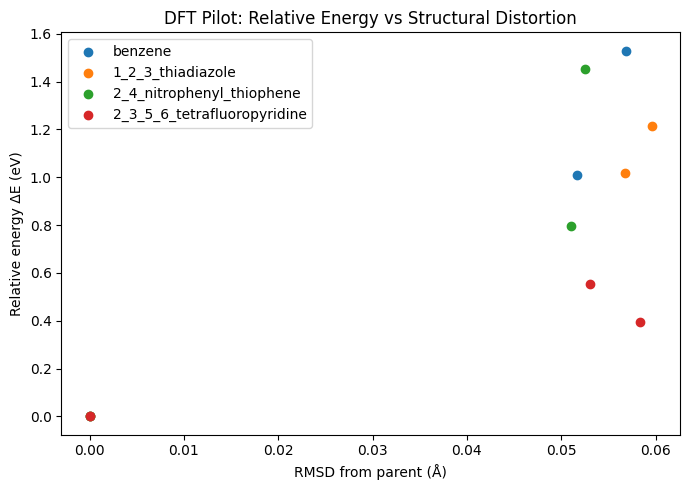

Saved: /content/drive/MyDrive/MLIP project/results/figures/dft_pilot_relative_energy_vs_rmsd.png


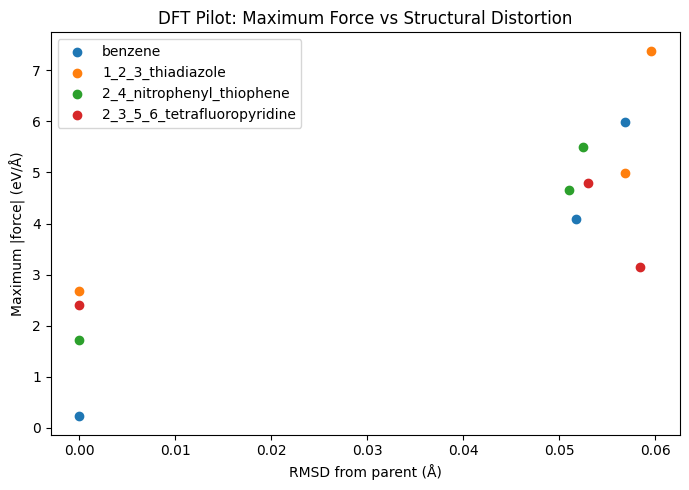

Saved: /content/drive/MyDrive/MLIP project/results/figures/dft_pilot_max_force_vs_rmsd.png


In [ ]:
# ============================================================
# CELL 26 — CREATE DFT PILOT QC PLOTS
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# PLOT 1 — RELATIVE ENERGY VS RMSD
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

for molecule_id, group in pilot_analysis_df.groupby(
    "molecule_id"
):

    plt.scatter(
        group["rmsd_from_parent_A"],
        group["delta_E_eV"],
        label=group["molecule_name"].iloc[0]
    )

plt.xlabel("RMSD from parent (Å)")
plt.ylabel("Relative energy ΔE (eV)")
plt.title(
    "DFT Pilot: Relative Energy vs Structural Distortion"
)

plt.legend()
plt.tight_layout()

plot1 = (
    FIGURES_DIR /
    "dft_pilot_relative_energy_vs_rmsd.png"
)

plt.savefig(
    plot1,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {plot1}")


# ------------------------------------------------------------
# PLOT 2 — MAXIMUM FORCE VS RMSD
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

for molecule_id, group in pilot_analysis_df.groupby(
    "molecule_id"
):

    plt.scatter(
        group["rmsd_from_parent_A"],
        group["max_force_eV_A"],
        label=group["molecule_name"].iloc[0]
    )

plt.xlabel("RMSD from parent (Å)")
plt.ylabel("Maximum |force| (eV/Å)")
plt.title(
    "DFT Pilot: Maximum Force vs Structural Distortion"
)

plt.legend()
plt.tight_layout()

plot2 = (
    FIGURES_DIR /
    "dft_pilot_max_force_vs_rmsd.png"
)

plt.savefig(
    plot2,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {plot2}")

In [ ]:
# ============================================================
# CELL 27 — SAVE PILOT ANALYSIS
# ============================================================

pilot_analysis_file = (
    RESULTS_DIR /
    "dft_pilot_analysis.csv"
)

pilot_analysis_df.to_csv(
    pilot_analysis_file,
    index=False
)

print("=" * 70)
print("PILOT ANALYSIS SAVED")
print("=" * 70)

print(f"File : {pilot_analysis_file}")
print(f"Rows : {len(pilot_analysis_df)}")

print("\nPilot analysis completed successfully.")

PILOT ANALYSIS SAVED
File : /content/drive/MyDrive/MLIP project/results/dft_pilot_analysis.csv
Rows : 12

Pilot analysis completed successfully.


In [ ]:
# ============================================================
# CELL 28 — PREPARE FULL DFT DATASET
# ============================================================

import json
import pandas as pd
import numpy as np
from pathlib import Path

print("=" * 70)
print("PREPARING FULL DFT DATASET")
print("=" * 70)

# ------------------------------------------------------------
# Reload the FINAL 563-configuration manifest
# ------------------------------------------------------------

MANIFEST_FILE = (
    PROCESSED_DIR /
    "configuration_manifest.csv"
)

manifest = pd.read_csv(MANIFEST_FILE)

print(f"Configurations : {len(manifest)}")
print(f"Molecules      : {manifest['molecule_id'].nunique()}")
print(f"Families       : {manifest['family'].nunique()}")

assert len(manifest) == 563
assert manifest["configuration_id"].is_unique

# ------------------------------------------------------------
# Required directories
# ------------------------------------------------------------

DFT_DIR.mkdir(parents=True, exist_ok=True)
DFT_INPUT_DIR.mkdir(parents=True, exist_ok=True)
DFT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DFT_FAILED_DIR.mkdir(parents=True, exist_ok=True)
DFT_PARSED_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Check all XYZ files
# ------------------------------------------------------------

missing_xyz = []

for _, row in manifest.iterrows():

    xyz_file = Path(row["xyz_path"])

    if not xyz_file.exists():
        missing_xyz.append(str(xyz_file))

print(f"Missing XYZ files : {len(missing_xyz)}")

assert len(missing_xyz) == 0, (
    f"{len(missing_xyz)} XYZ files are missing."
)

# ------------------------------------------------------------
# Count existing DFT results
# ------------------------------------------------------------

completed = 0
remaining = 0

for job_id in manifest["configuration_id"]:

    output_file = DFT_OUTPUT_DIR / f"{job_id}.json"

    if output_file.exists():
        completed += 1
    else:
        remaining += 1

print(f"Existing DFT results : {completed}")
print(f"Remaining DFT jobs   : {remaining}")

print("\nFULL DFT DATASET IS READY.")

In [ ]:
# ============================================================
# CELL 29 — CREATE FINAL DFT JOB MANIFEST
# ============================================================

print("=" * 70)
print("CREATING FINAL DFT JOB MANIFEST")
print("=" * 70)

final_dft_manifest = manifest.copy()

final_dft_manifest["output_json"] = (
    final_dft_manifest["configuration_id"]
    .apply(
        lambda x: str(
            DFT_OUTPUT_DIR / f"{x}.json"
        )
    )
)

final_dft_manifest["status"] = (
    final_dft_manifest["configuration_id"]
    .apply(
        lambda x:
        "completed"
        if (
            DFT_OUTPUT_DIR / f"{x}.json"
        ).exists()
        else "pending"
    )
)

FINAL_DFT_MANIFEST_FILE = (
    PROCESSED_DIR /
    "dft_full_manifest.csv"
)

final_dft_manifest.to_csv(
    FINAL_DFT_MANIFEST_FILE,
    index=False
)

print(f"Manifest saved to:")
print(FINAL_DFT_MANIFEST_FILE)

print("\nStatus summary:")
print(
    final_dft_manifest["status"]
    .value_counts()
)

display(
    final_dft_manifest[
        [
            "molecule_id",
            "molecule_name",
            "family",
            "configuration_id",
            "status"
        ]
    ].head(20)
)

In [ ]:
# ============================================================
# D3BJ BACKEND RECOVERY
# ============================================================

import sys
import subprocess
import importlib

print("=" * 70)
print("CHECKING PYS CF D3BJ BACKEND")
print("=" * 70)

# 1. Install/reinstall the required dispersion package
subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "--upgrade",
    "pyscf-dispersion"
])

print("\npyscf-dispersion installation completed.")

# 2. Reload PySCF dispersion modules
import pyscf
import pyscf.dispersion.dftd3
import pyscf.scf.dispersion as scf_dispersion

scf_dispersion = importlib.reload(scf_dispersion)

print("PySCF version:", pyscf.__version__)
print("dftd3 object :", scf_dispersion.dftd3)
print("dftd4 object :", scf_dispersion.dftd4)

assert scf_dispersion.dftd3 is not None, (
    "D3BJ backend is still unavailable."
)

print("\n" + "=" * 70)
print("D3BJ BACKEND IS AVAILABLE")
print("=" * 70)

In [ ]:
# ============================================================
# TEST D3BJ ON ONE FAILED CONFIGURATION
# ============================================================

test_job = "M04_C016"

test_row = manifest[
    manifest["configuration_id"] == test_job
].iloc[0]

test_input = Path(test_row["xyz_path"])
test_output = DFT_OUTPUT_DIR / f"{test_job}_retest.json"

print("=" * 70)
print("D3BJ RETEST")
print("=" * 70)
print("Job      :", test_job)
print("Molecule :", test_row["molecule_name"])
print("Input    :", test_input)
print("Output   :", test_output)

result = run_pyscf_dft_job(
    xyz_file=test_input,
    output_file=test_output,
    method="PBE0",
    dispersion="D3BJ",
    basis="def2-SVP",
    charge=0,
    spin=0
)

print("\n" + "=" * 70)
print("RETEST SUCCESSFUL")
print("=" * 70)
print(f"Energy      : {result['energy_eV']:.8f} eV")
print(f"Max |force| : {result['max_force_eV_A']:.8f} eV/Å")
print(f"SCF cycles  : {result['scf_cycles']}")
print(f"Runtime     : {result['runtime_seconds']:.2f} s")

In [ ]:
# ============================================================
# CELL 30 — RUN FULL DFT DATASET
# ============================================================

import json
import time
import traceback
import numpy as np
import pandas as pd
from pathlib import Path

print("=" * 70)
print("RUNNING FULL DFT DATASET")
print("=" * 70)

# ------------------------------------------------------------
# Define final manifest path directly
# ------------------------------------------------------------

FINAL_DFT_MANIFEST_FILE = (
    PROCESSED_DIR /
    "dft_full_manifest.csv"
)

# Check that the manifest exists
if not FINAL_DFT_MANIFEST_FILE.exists():
    raise FileNotFoundError(
        f"Final DFT manifest not found:\n"
        f"{FINAL_DFT_MANIFEST_FILE}\n\n"
        "Run Cell 29 first."
    )

# ------------------------------------------------------------
# Load final 563-configuration manifest
# ------------------------------------------------------------

manifest = pd.read_csv(
    FINAL_DFT_MANIFEST_FILE
)

print(f"Total configurations : {len(manifest)}")

assert len(manifest) == 563
assert manifest["configuration_id"].is_unique

# ------------------------------------------------------------
# Make sure DFT directories exist
# ------------------------------------------------------------

DFT_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DFT_FAILED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# Run DFT calculations
# ------------------------------------------------------------

successful = 0
skipped = 0
failed = 0

start_all = time.time()

for i, row in manifest.iterrows():

    job_id = row["configuration_id"]

    input_file = Path(row["xyz_path"])
    output_file = (
        DFT_OUTPUT_DIR /
        f"{job_id}.json"
    )
    failed_file = (
        DFT_FAILED_DIR /
        f"{job_id}_failed.json"
    )

    print("\n" + "=" * 70)
    print(
        f"JOB {i + 1}/{len(manifest)}"
    )
    print(f"ID       : {job_id}")
    print(f"Molecule : {row['molecule_name']}")
    print(f"Family   : {row['family']}")
    print("=" * 70)

    # --------------------------------------------------------
    # Skip completed jobs
    # --------------------------------------------------------

    if output_file.exists():

        print("STATUS: COMPLETED — SKIPPING")

        skipped += 1
        continue

    # --------------------------------------------------------
    # Check input XYZ
    # --------------------------------------------------------

    if not input_file.exists():

        print("STATUS: FAILED — XYZ FILE NOT FOUND")

        error_record = {
            "configuration_id": job_id,
            "molecule_id": row["molecule_id"],
            "molecule_name": row["molecule_name"],
            "family": row["family"],
            "status": "failed",
            "error": f"XYZ file not found: {input_file}"
        }

        with open(failed_file, "w") as f:
            json.dump(
                error_record,
                f,
                indent=2
            )

        failed += 1
        continue

    # --------------------------------------------------------
    # Run PySCF DFT
    # --------------------------------------------------------

    try:

        result = run_pyscf_dft_job(
            xyz_file=input_file,
            output_file=output_file,
            method="PBE0",
            dispersion="D3BJ",
            basis="def2-SVP",
            charge=0,
            spin=0
        )

        # Add configuration metadata
        result["configuration_id"] = job_id
        result["molecule_id"] = row["molecule_id"]
        result["molecule_name"] = row["molecule_name"]
        result["family"] = row["family"]
        result["perturbation_sigma_A"] = float(
            row["perturbation_sigma_A"]
        )
        result["rmsd_from_parent_A"] = float(
            row["rmsd_from_parent_A"]
        )

        # Save updated JSON
        with open(output_file, "w") as f:
            json.dump(
                result,
                f,
                indent=2
            )

        successful += 1

        print("STATUS: SUCCESS")
        print(
            f"Energy      : "
            f"{result['energy_eV']:.8f} eV"
        )
        print(
            f"Max |force| : "
            f"{result['max_force_eV_A']:.8f} eV/Å"
        )
        print(
            f"SCF cycles  : "
            f"{result['scf_cycles']}"
        )
        print(
            f"Runtime     : "
            f"{result['runtime_seconds']:.2f} s"
        )

    except Exception as exc:

        failed += 1

        error_record = {
            "configuration_id": job_id,
            "molecule_id": row["molecule_id"],
            "molecule_name": row["molecule_name"],
            "family": row["family"],
            "status": "failed",
            "error": str(exc),
            "traceback": traceback.format_exc()
        }

        with open(failed_file, "w") as f:
            json.dump(
                error_record,
                f,
                indent=2
            )

        print("STATUS: FAILED")
        print(f"Error: {exc}")


# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------

elapsed_all = time.time() - start_all

print("\n" + "=" * 70)
print("FULL DFT RUN FINISHED")
print("=" * 70)

print(f"Total jobs       : {len(manifest)}")
print(f"New successful   : {successful}")
print(f"Skipped existing : {skipped}")
print(f"Failed           : {failed}")
print(
    f"Elapsed time     : "
    f"{elapsed_all / 3600:.2f} hours"
)

print("=" * 70)

RUNNING FULL DFT DATASET
Total configurations : 563

JOB 1/563
ID       : M01_C001
Molecule : benzene
Family   : aromatic_hydrocarbon
STATUS: COMPLETED — SKIPPING

JOB 2/563
ID       : M01_C002
Molecule : benzene
Family   : aromatic_hydrocarbon
STATUS: COMPLETED — SKIPPING

JOB 3/563
ID       : M01_C003
Molecule : benzene
Family   : aromatic_hydrocarbon
STATUS: COMPLETED — SKIPPING

JOB 4/563
ID       : M01_C004
Molecule : benzene
Family   : aromatic_hydrocarbon
STATUS: COMPLETED — SKIPPING

JOB 5/563
ID       : M01_C005
Molecule : benzene
Family   : aromatic_hydrocarbon
STATUS: COMPLETED — SKIPPING

JOB 6/563
ID       : M01_C006
Molecule : benzene
Family   : aromatic_hydrocarbon
STATUS: COMPLETED — SKIPPING

JOB 7/563
ID       : M01_C007
Molecule : benzene
Family   : aromatic_hydrocarbon
STATUS: COMPLETED — SKIPPING

JOB 8/563
ID       : M01_C008
Molecule : benzene
Family   : aromatic_hydrocarbon
STATUS: COMPLETED — SKIPPING

JOB 9/563
ID       : M01_C009
Molecule : benzene
Family   :

In [ ]:
# ============================================================
# CELL 30B — RUN DFT IN BATCHES
# ============================================================

import json
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# BATCH SETTINGS
# ------------------------------------------------------------

BATCH_START = 87     # inclusive
BATCH_END   = 156    # inclusive

batch_manifest = manifest.iloc[BATCH_START - 1:BATCH_END].copy()

print("=" * 70)
print("DFT BATCH")
print("=" * 70)
print(f"Batch range : {BATCH_START} - {BATCH_END}")
print(f"Jobs in batch: {len(batch_manifest)}")
print("=" * 70)

successful = 0
skipped = 0
failed = 0

for batch_number, (_, row) in enumerate(
    batch_manifest.iterrows(),
    start=BATCH_START
):

    job_id = row["configuration_id"]

    input_file = Path(row["xyz_path"])
    output_file = DFT_OUTPUT_DIR / f"{job_id}.json"

    print("\n" + "-" * 70)
    print(f"JOB {batch_number}/563")
    print(f"ID       : {job_id}")
    print(f"Molecule : {row['molecule_name']}")
    print(f"Family   : {row['family']}")

    # --------------------------------------------------------
    # CHECK EXISTING OUTPUT
    # --------------------------------------------------------

    if output_file.exists():

        try:
            with open(output_file, "r") as f:
                old_result = json.load(f)

            forces = np.asarray(
                old_result.get("forces_eV_A", []),
                dtype=float
            )

            energy = old_result.get("energy_eV", None)

            valid_existing = (
                old_result.get("status") == "success"
                and energy is not None
                and np.isfinite(float(energy))
                and forces.shape == (int(row["n_atoms"]), 3)
                and np.all(np.isfinite(forces))
                and old_result.get("scf_converged", False)
            )

            if valid_existing:
                print("STATUS: COMPLETED — SKIPPING")
                skipped += 1
                continue

        except Exception:
            pass

    # --------------------------------------------------------
    # RUN DFT
    # --------------------------------------------------------

    print("STATUS: RUNNING")

    try:

        result = run_pyscf_dft_job(
            xyz_file=input_file,
            output_file=output_file,
            method="PBE0",
            dispersion="D3BJ",
            basis="def2-SVP",
            charge=0,
            spin=0
        )

        # Add current manifest metadata
        result.update({
            "configuration_id": job_id,
            "molecule_id": row["molecule_id"],
            "molecule_name": row["molecule_name"],
            "family": row["family"],
        })

        with open(output_file, "w") as f:
            json.dump(result, f, indent=2)

        successful += 1

        print(
            f"STATUS: SUCCESS | "
            f"E = {result['energy_eV']:.6f} eV | "
            f"max|F| = {result['max_force_eV_A']:.6f} eV/A"
        )

    except Exception as exc:

        failed += 1

        print("STATUS: FAILED")
        print("Error:", exc)

        failed_file = (
            DFT_FAILED_DIR /
            f"{job_id}_failed.json"
        )

        failure_record = {
            "configuration_id": job_id,
            "molecule_id": row["molecule_id"],
            "molecule_name": row["molecule_name"],
            "family": row["family"],
            "status": "failed",
            "error": str(exc),
            "xyz_file": str(input_file)
        }

        with open(failed_file, "w") as f:
            json.dump(failure_record, f, indent=2)

# ------------------------------------------------------------
# BATCH SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BATCH COMPLETE")
print("=" * 70)
print(f"Batch range : {BATCH_START} - {BATCH_END}")
print(f"Successful  : {successful}")
print(f"Skipped     : {skipped}")
print(f"Failed      : {failed}")
print("=" * 70)

DFT BATCH
Batch range : 87 - 156
Jobs in batch: 70

----------------------------------------------------------------------
JOB 87/563
ID       : M04_C016
Molecule : anthracene
Family   : aromatic_hydrocarbon
STATUS: COMPLETED — SKIPPING

----------------------------------------------------------------------
JOB 88/563
ID       : M04_C017
Molecule : anthracene
Family   : aromatic_hydrocarbon
STATUS: COMPLETED — SKIPPING

----------------------------------------------------------------------
JOB 89/563
ID       : M04_C018
Molecule : anthracene
Family   : aromatic_hydrocarbon
STATUS: COMPLETED — SKIPPING

----------------------------------------------------------------------
JOB 90/563
ID       : M04_C019
Molecule : anthracene
Family   : aromatic_hydrocarbon
STATUS: COMPLETED — SKIPPING

----------------------------------------------------------------------
JOB 91/563
ID       : M04_C020
Molecule : anthracene
Family   : aromatic_hydrocarbon
STATUS: COMPLETED — SKIPPING

------------------

In [ ]:
# ============================================================
# RESTORE run_pyscf_dft_job()
# PBE0-D3(BJ)/def2-SVP
# Single-point energy + analytic nuclear gradient
# ============================================================

import json
import time
import numpy as np
from pathlib import Path

from ase.io import read
from ase.units import Hartree, Bohr

from pyscf import gto, dft


# ------------------------------------------------------------
# UNIT CONVERSIONS
# ------------------------------------------------------------

HARTREE_TO_EV = Hartree
HARTREE_BOHR_TO_EV_A = Hartree / Bohr


# ------------------------------------------------------------
# DFT JOB FUNCTION
# ------------------------------------------------------------

def run_pyscf_dft_job(
    xyz_file,
    output_file,
    method="PBE0",
    dispersion="D3BJ",
    basis="def2-SVP",
    charge=0,
    spin=0
):

    xyz_file = Path(xyz_file)
    output_file = Path(output_file)

    start_time = time.time()

    # --------------------------------------------------------
    # READ XYZ
    # --------------------------------------------------------

    atoms = read(str(xyz_file))

    atom_data = [
        (
            symbol,
            tuple(float(x) for x in position)
        )
        for symbol, position
        in zip(
            atoms.get_chemical_symbols(),
            atoms.get_positions()
        )
    ]

    # --------------------------------------------------------
    # BUILD PySCF MOLECULE
    # --------------------------------------------------------

    mol = gto.M(
        atom=atom_data,
        basis=basis,
        charge=charge,
        spin=spin,
        unit="Angstrom",
        verbose=0
    )

    # --------------------------------------------------------
    # PBE0-D3(BJ)
    # --------------------------------------------------------

    mf = dft.RKS(mol)

    mf.xc = "pbe0-d3bj"

    mf.conv_tol = 1e-9
    mf.conv_tol_grad = 1e-6
    mf.max_cycle = 150

    # --------------------------------------------------------
    # SCF
    # --------------------------------------------------------

    energy_hartree = mf.kernel()

    if not mf.converged:
        raise RuntimeError(
            "SCF failed to converge."
        )

    # --------------------------------------------------------
    # ANALYTIC NUCLEAR GRADIENT
    # --------------------------------------------------------

    grad_method = mf.nuc_grad_method()

    gradient_hartree_bohr = grad_method.kernel()

    # --------------------------------------------------------
    # VALIDATE GRADIENT
    # --------------------------------------------------------

    expected_shape = (mol.natm, 3)

    if gradient_hartree_bohr.shape != expected_shape:
        raise RuntimeError(
            f"Unexpected gradient shape: "
            f"{gradient_hartree_bohr.shape}; "
            f"expected {expected_shape}"
        )

    if not np.all(
        np.isfinite(gradient_hartree_bohr)
    ):
        raise RuntimeError(
            "Gradient contains non-finite values."
        )

    # --------------------------------------------------------
    # CONVERT ENERGY
    # --------------------------------------------------------

    energy_eV = (
        energy_hartree *
        HARTREE_TO_EV
    )

    # --------------------------------------------------------
    # GRADIENT -> FORCE
    #
    # Force = -gradient
    # --------------------------------------------------------

    forces_eV_A = (
        -gradient_hartree_bohr *
        HARTREE_BOHR_TO_EV_A
    )

    # --------------------------------------------------------
    # RUNTIME
    # --------------------------------------------------------

    elapsed = time.time() - start_time

    # --------------------------------------------------------
    # RESULT
    # --------------------------------------------------------

    result = {

        "status": "success",

        "xyz_file": str(xyz_file),

        "n_atoms": int(mol.natm),

        "energy_hartree":
            float(energy_hartree),

        "energy_eV":
            float(energy_eV),

        "forces_eV_A":
            forces_eV_A.tolist(),

        "max_force_eV_A":
            float(
                np.max(
                    np.abs(forces_eV_A)
                )
            ),

        "scf_converged":
            bool(mf.converged),

        "scf_cycles":
            int(
                getattr(
                    mf,
                    "cycles",
                    -1
                )
            ),

        "runtime_seconds":
            float(elapsed),

        "method":
            method,

        "dispersion":
            dispersion,

        "basis":
            basis,

        "charge":
            charge,

        "spin":
            spin,

        "software":
            "PySCF"
    }

    # --------------------------------------------------------
    # SAVE RESULT
    # --------------------------------------------------------

    output_file.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    with open(
        output_file,
        "w"
    ) as f:

        json.dump(
            result,
            f,
            indent=2
        )

    return result


# ============================================================
# FUNCTION CHECK
# ============================================================

print("=" * 70)
print("DFT FUNCTION RESTORED")
print("=" * 70)

print(run_pyscf_dft_job)

print("\nPySCF version:", __import__("pyscf").__version__)

print("=" * 70)

DFT FUNCTION RESTORED
<function run_pyscf_dft_job at 0x780b7857f420>

PySCF version: 2.14.0


In [ ]:
# ============================================================
# CELL 30C — RUN DFT IN BATCHES
# ============================================================

# ============================================================
# CELL 30B — RUN DFT IN BATCHES
# ============================================================

import json
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# BATCH SETTINGS
# ------------------------------------------------------------

BATCH_START = 157     # inclusive
BATCH_END   = 226     # inclusive

batch_manifest = manifest.iloc[BATCH_START - 1:BATCH_END].copy()

print("=" * 70)
print("DFT BATCH")
print("=" * 70)
print(f"Batch range : {BATCH_START} - {BATCH_END}")
print(f"Jobs in batch: {len(batch_manifest)}")
print("=" * 70)

successful = 0
skipped = 0
failed = 0

for batch_number, (_, row) in enumerate(
    batch_manifest.iterrows(),
    start=BATCH_START
):

    job_id = row["configuration_id"]

    input_file = Path(row["xyz_path"])
    output_file = DFT_OUTPUT_DIR / f"{job_id}.json"

    print("\n" + "-" * 70)
    print(f"JOB {batch_number}/563")
    print(f"ID       : {job_id}")
    print(f"Molecule : {row['molecule_name']}")
    print(f"Family   : {row['family']}")

    # --------------------------------------------------------
    # CHECK EXISTING OUTPUT
    # --------------------------------------------------------

    if output_file.exists():

        try:
            with open(output_file, "r") as f:
                old_result = json.load(f)

            forces = np.asarray(
                old_result.get("forces_eV_A", []),
                dtype=float
            )

            energy = old_result.get("energy_eV", None)

            valid_existing = (
                old_result.get("status") == "success"
                and energy is not None
                and np.isfinite(float(energy))
                and forces.shape == (int(row["n_atoms"]), 3)
                and np.all(np.isfinite(forces))
                and old_result.get("scf_converged", False)
            )

            if valid_existing:
                print("STATUS: COMPLETED — SKIPPING")
                skipped += 1
                continue

        except Exception:
            pass

    # --------------------------------------------------------
    # RUN DFT
    # --------------------------------------------------------

    print("STATUS: RUNNING")

    try:

        result = run_pyscf_dft_job(
            xyz_file=input_file,
            output_file=output_file,
            method="PBE0",
            dispersion="D3BJ",
            basis="def2-SVP",
            charge=0,
            spin=0
        )

        # Add current manifest metadata
        result.update({
            "configuration_id": job_id,
            "molecule_id": row["molecule_id"],
            "molecule_name": row["molecule_name"],
            "family": row["family"],
        })

        with open(output_file, "w") as f:
            json.dump(result, f, indent=2)

        successful += 1

        print(
            f"STATUS: SUCCESS | "
            f"E = {result['energy_eV']:.6f} eV | "
            f"max|F| = {result['max_force_eV_A']:.6f} eV/A"
        )

    except Exception as exc:

        failed += 1

        print("STATUS: FAILED")
        print("Error:", exc)

        failed_file = (
            DFT_FAILED_DIR /
            f"{job_id}_failed.json"
        )

        failure_record = {
            "configuration_id": job_id,
            "molecule_id": row["molecule_id"],
            "molecule_name": row["molecule_name"],
            "family": row["family"],
            "status": "failed",
            "error": str(exc),
            "xyz_file": str(input_file)
        }

        with open(failed_file, "w") as f:
            json.dump(failure_record, f, indent=2)

# ------------------------------------------------------------
# BATCH SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BATCH COMPLETE")
print("=" * 70)
print(f"Batch range : {BATCH_START} - {BATCH_END}")
print(f"Successful  : {successful}")
print(f"Skipped     : {skipped}")
print(f"Failed      : {failed}")
print("=" * 70)

DFT BATCH
Batch range : 157 - 226
Jobs in batch: 70

----------------------------------------------------------------------
JOB 157/563
ID       : M07_C016
Molecule : pyridine
Family   : O_N_aromatic
STATUS: COMPLETED — SKIPPING

----------------------------------------------------------------------
JOB 158/563
ID       : M07_C017
Molecule : pyridine
Family   : O_N_aromatic
STATUS: COMPLETED — SKIPPING

----------------------------------------------------------------------
JOB 159/563
ID       : M07_C018
Molecule : pyridine
Family   : O_N_aromatic
STATUS: COMPLETED — SKIPPING

----------------------------------------------------------------------
JOB 160/563
ID       : M08_C001
Molecule : aniline
Family   : O_N_aromatic
STATUS: COMPLETED — SKIPPING

----------------------------------------------------------------------
JOB 161/563
ID       : M08_C002
Molecule : aniline
Family   : O_N_aromatic
STATUS: COMPLETED — SKIPPING

----------------------------------------------------------------

In [ ]:
# ============================================================
# CELL 30D — RUN DFT IN BATCHES
# ============================================================

# ============================================================
# ============================================================

import json
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# BATCH SETTINGS
# ------------------------------------------------------------

BATCH_START = 227    # inclusive
BATCH_END   = 337     # inclusive

batch_manifest = manifest.iloc[BATCH_START - 1:BATCH_END].copy()

print("=" * 70)
print("DFT BATCH")
print("=" * 70)
print(f"Batch range : {BATCH_START} - {BATCH_END}")
print(f"Jobs in batch: {len(batch_manifest)}")
print("=" * 70)

successful = 0
skipped = 0
failed = 0

for batch_number, (_, row) in enumerate(
    batch_manifest.iterrows(),
    start=BATCH_START
):

    job_id = row["configuration_id"]

    input_file = Path(row["xyz_path"])
    output_file = DFT_OUTPUT_DIR / f"{job_id}.json"

    print("\n" + "-" * 70)
    print(f"JOB {batch_number}/563")
    print(f"ID       : {job_id}")
    print(f"Molecule : {row['molecule_name']}")
    print(f"Family   : {row['family']}")

    # --------------------------------------------------------
    # CHECK EXISTING OUTPUT
    # --------------------------------------------------------

    if output_file.exists():

        try:
            with open(output_file, "r") as f:
                old_result = json.load(f)

            forces = np.asarray(
                old_result.get("forces_eV_A", []),
                dtype=float
            )

            energy = old_result.get("energy_eV", None)

            valid_existing = (
                old_result.get("status") == "success"
                and energy is not None
                and np.isfinite(float(energy))
                and forces.shape == (int(row["n_atoms"]), 3)
                and np.all(np.isfinite(forces))
                and old_result.get("scf_converged", False)
            )

            if valid_existing:
                print("STATUS: COMPLETED — SKIPPING")
                skipped += 1
                continue

        except Exception:
            pass

    # --------------------------------------------------------
    # RUN DFT
    # --------------------------------------------------------

    print("STATUS: RUNNING")

    try:

        result = run_pyscf_dft_job(
            xyz_file=input_file,
            output_file=output_file,
            method="PBE0",
            dispersion="D3BJ",
            basis="def2-SVP",
            charge=0,
            spin=0
        )

        # Add current manifest metadata
        result.update({
            "configuration_id": job_id,
            "molecule_id": row["molecule_id"],
            "molecule_name": row["molecule_name"],
            "family": row["family"],
        })

        with open(output_file, "w") as f:
            json.dump(result, f, indent=2)

        successful += 1

        print(
            f"STATUS: SUCCESS | "
            f"E = {result['energy_eV']:.6f} eV | "
            f"max|F| = {result['max_force_eV_A']:.6f} eV/A"
        )

    except Exception as exc:

        failed += 1

        print("STATUS: FAILED")
        print("Error:", exc)

        failed_file = (
            DFT_FAILED_DIR /
            f"{job_id}_failed.json"
        )

        failure_record = {
            "configuration_id": job_id,
            "molecule_id": row["molecule_id"],
            "molecule_name": row["molecule_name"],
            "family": row["family"],
            "status": "failed",
            "error": str(exc),
            "xyz_file": str(input_file)
        }

        with open(failed_file, "w") as f:
            json.dump(failure_record, f, indent=2)

# ------------------------------------------------------------
# BATCH SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BATCH COMPLETE")
print("=" * 70)
print(f"Batch range : {BATCH_START} - {BATCH_END}")
print(f"Successful  : {successful}")
print(f"Skipped     : {skipped}")
print(f"Failed      : {failed}")
print("=" * 70)

DFT BATCH
Batch range : 227 - 337
Jobs in batch: 111

----------------------------------------------------------------------
JOB 227/563
ID       : M10_C024
Molecule : BDT
Family   : S_heteroaromatic
STATUS: COMPLETED — SKIPPING

----------------------------------------------------------------------
JOB 228/563
ID       : M11_C001
Molecule : benzobithiophene
Family   : S_heteroaromatic
STATUS: COMPLETED — SKIPPING

----------------------------------------------------------------------
JOB 229/563
ID       : M11_C002
Molecule : benzobithiophene
Family   : S_heteroaromatic
STATUS: COMPLETED — SKIPPING

----------------------------------------------------------------------
JOB 230/563
ID       : M11_C003
Molecule : benzobithiophene
Family   : S_heteroaromatic
STATUS: COMPLETED — SKIPPING

----------------------------------------------------------------------
JOB 231/563
ID       : M11_C004
Molecule : benzobithiophene
Family   : S_heteroaromatic
STATUS: COMPLETED — SKIPPING

--------------

In [ ]:
# ============================================================
# CELL 30D — RUN DFT IN BATCHES
# ============================================================

# ============================================================
# ============================================================

import json
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# BATCH SETTINGS
# ------------------------------------------------------------

BATCH_START = 227    # inclusive
BATCH_END   = 337     # inclusive

batch_manifest = manifest.iloc[BATCH_START - 1:BATCH_END].copy()

print("=" * 70)
print("DFT BATCH")
print("=" * 70)
print(f"Batch range : {BATCH_START} - {BATCH_END}")
print(f"Jobs in batch: {len(batch_manifest)}")
print("=" * 70)

successful = 0
skipped = 0
failed = 0

for batch_number, (_, row) in enumerate(
    batch_manifest.iterrows(),
    start=BATCH_START
):

    job_id = row["configuration_id"]

    input_file = Path(row["xyz_path"])
    output_file = DFT_OUTPUT_DIR / f"{job_id}.json"

    print("\n" + "-" * 70)
    print(f"JOB {batch_number}/563")
    print(f"ID       : {job_id}")
    print(f"Molecule : {row['molecule_name']}")
    print(f"Family   : {row['family']}")

    # --------------------------------------------------------
    # CHECK EXISTING OUTPUT
    # --------------------------------------------------------

    if output_file.exists():

        try:
            with open(output_file, "r") as f:
                old_result = json.load(f)

            forces = np.asarray(
                old_result.get("forces_eV_A", []),
                dtype=float
            )

            energy = old_result.get("energy_eV", None)

            valid_existing = (
                old_result.get("status") == "success"
                and energy is not None
                and np.isfinite(float(energy))
                and forces.shape == (int(row["n_atoms"]), 3)
                and np.all(np.isfinite(forces))
                and old_result.get("scf_converged", False)
            )

            if valid_existing:
                print("STATUS: COMPLETED — SKIPPING")
                skipped += 1
                continue

        except Exception:
            pass

    # --------------------------------------------------------
    # RUN DFT
    # --------------------------------------------------------

    print("STATUS: RUNNING")

    try:

        result = run_pyscf_dft_job(
            xyz_file=input_file,
            output_file=output_file,
            method="PBE0",
            dispersion="D3BJ",
            basis="def2-SVP",
            charge=0,
            spin=0
        )

        # Add current manifest metadata
        result.update({
            "configuration_id": job_id,
            "molecule_id": row["molecule_id"],
            "molecule_name": row["molecule_name"],
            "family": row["family"],
        })

        with open(output_file, "w") as f:
            json.dump(result, f, indent=2)

        successful += 1

        print(
            f"STATUS: SUCCESS | "
            f"E = {result['energy_eV']:.6f} eV | "
            f"max|F| = {result['max_force_eV_A']:.6f} eV/A"
        )

    except Exception as exc:

        failed += 1

        print("STATUS: FAILED")
        print("Error:", exc)

        failed_file = (
            DFT_FAILED_DIR /
            f"{job_id}_failed.json"
        )

        failure_record = {
            "configuration_id": job_id,
            "molecule_id": row["molecule_id"],
            "molecule_name": row["molecule_name"],
            "family": row["family"],
            "status": "failed",
            "error": str(exc),
            "xyz_file": str(input_file)
        }

        with open(failed_file, "w") as f:
            json.dump(failure_record, f, indent=2)

# ------------------------------------------------------------
# BATCH SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BATCH COMPLETE")
print("=" * 70)
print(f"Batch range : {BATCH_START} - {BATCH_END}")
print(f"Successful  : {successful}")
print(f"Skipped     : {skipped}")
print(f"Failed      : {failed}")
print("=" * 70)

DFT BATCH
Batch range : 227 - 337
Jobs in batch: 111

----------------------------------------------------------------------
JOB 227/563
ID       : M10_C024
Molecule : BDT
Family   : S_heteroaromatic
STATUS: COMPLETED — SKIPPING

----------------------------------------------------------------------
JOB 228/563
ID       : M11_C001
Molecule : benzobithiophene
Family   : S_heteroaromatic
STATUS: COMPLETED — SKIPPING

----------------------------------------------------------------------
JOB 229/563
ID       : M11_C002
Molecule : benzobithiophene
Family   : S_heteroaromatic
STATUS: COMPLETED — SKIPPING

----------------------------------------------------------------------
JOB 230/563
ID       : M11_C003
Molecule : benzobithiophene
Family   : S_heteroaromatic
STATUS: COMPLETED — SKIPPING

----------------------------------------------------------------------
JOB 231/563
ID       : M11_C004
Molecule : benzobithiophene
Family   : S_heteroaromatic
STATUS: COMPLETED — SKIPPING

--------------

In [ ]:
# ============================================================
# CELL 30E — RUN DFT IN BATCHES
# ============================================================

# ============================================================
# ============================================================

import json
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# BATCH SETTINGS
# ------------------------------------------------------------

BATCH_START = 338    # inclusive
BATCH_END   = 563     # inclusive

batch_manifest = manifest.iloc[BATCH_START - 1:BATCH_END].copy()

print("=" * 70)
print("DFT BATCH")
print("=" * 70)
print(f"Batch range : {BATCH_START} - {BATCH_END}")
print(f"Jobs in batch: {len(batch_manifest)}")
print("=" * 70)

successful = 0
skipped = 0
failed = 0

for batch_number, (_, row) in enumerate(
    batch_manifest.iterrows(),
    start=BATCH_START
):

    job_id = row["configuration_id"]

    input_file = Path(row["xyz_path"])
    output_file = DFT_OUTPUT_DIR / f"{job_id}.json"

    print("\n" + "-" * 70)
    print(f"JOB {batch_number}/563")
    print(f"ID       : {job_id}")
    print(f"Molecule : {row['molecule_name']}")
    print(f"Family   : {row['family']}")

    # --------------------------------------------------------
    # CHECK EXISTING OUTPUT
    # --------------------------------------------------------

    if output_file.exists():

        try:
            with open(output_file, "r") as f:
                old_result = json.load(f)

            forces = np.asarray(
                old_result.get("forces_eV_A", []),
                dtype=float
            )

            energy = old_result.get("energy_eV", None)

            valid_existing = (
                old_result.get("status") == "success"
                and energy is not None
                and np.isfinite(float(energy))
                and forces.shape == (int(row["n_atoms"]), 3)
                and np.all(np.isfinite(forces))
                and old_result.get("scf_converged", False)
            )

            if valid_existing:
                print("STATUS: COMPLETED — SKIPPING")
                skipped += 1
                continue

        except Exception:
            pass

    # --------------------------------------------------------
    # RUN DFT
    # --------------------------------------------------------

    print("STATUS: RUNNING")

    try:

        result = run_pyscf_dft_job(
            xyz_file=input_file,
            output_file=output_file,
            method="PBE0",
            dispersion="D3BJ",
            basis="def2-SVP",
            charge=0,
            spin=0
        )

        # Add current manifest metadata
        result.update({
            "configuration_id": job_id,
            "molecule_id": row["molecule_id"],
            "molecule_name": row["molecule_name"],
            "family": row["family"],
        })

        with open(output_file, "w") as f:
            json.dump(result, f, indent=2)

        successful += 1

        print(
            f"STATUS: SUCCESS | "
            f"E = {result['energy_eV']:.6f} eV | "
            f"max|F| = {result['max_force_eV_A']:.6f} eV/A"
        )

    except Exception as exc:

        failed += 1

        print("STATUS: FAILED")
        print("Error:", exc)

        failed_file = (
            DFT_FAILED_DIR /
            f"{job_id}_failed.json"
        )

        failure_record = {
            "configuration_id": job_id,
            "molecule_id": row["molecule_id"],
            "molecule_name": row["molecule_name"],
            "family": row["family"],
            "status": "failed",
            "error": str(exc),
            "xyz_file": str(input_file)
        }

        with open(failed_file, "w") as f:
            json.dump(failure_record, f, indent=2)

# ------------------------------------------------------------
# BATCH SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BATCH COMPLETE")
print("=" * 70)
print(f"Batch range : {BATCH_START} - {BATCH_END}")
print(f"Successful  : {successful}")
print(f"Skipped     : {skipped}")
print(f"Failed      : {failed}")
print("=" * 70)

DFT BATCH
Batch range : 338 - 563
Jobs in batch: 226

----------------------------------------------------------------------
JOB 338/563
ID       : M15_C015
Molecule : 4_nitrostyrene
Family   : donor_acceptor
STATUS: COMPLETED — SKIPPING

----------------------------------------------------------------------
JOB 339/563
ID       : M15_C016
Molecule : 4_nitrostyrene
Family   : donor_acceptor
STATUS: COMPLETED — SKIPPING

----------------------------------------------------------------------
JOB 340/563
ID       : M15_C017
Molecule : 4_nitrostyrene
Family   : donor_acceptor
STATUS: COMPLETED — SKIPPING

----------------------------------------------------------------------
JOB 341/563
ID       : M15_C018
Molecule : 4_nitrostyrene
Family   : donor_acceptor
STATUS: COMPLETED — SKIPPING

----------------------------------------------------------------------
JOB 342/563
ID       : M15_C019
Molecule : 4_nitrostyrene
Family   : donor_acceptor
STATUS: COMPLETED — SKIPPING

---------------------

In [ ]:
# ============================================================
# CELL 31 — VALIDATE ALL DFT RESULTS
# ============================================================

import json
import numpy as np
import pandas as pd
from pathlib import Path

print("=" * 70)
print("DFT RESULT VALIDATION")
print("=" * 70)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

EXPECTED_JOBS = 563

# ------------------------------------------------------------
# LOAD MANIFEST
# ------------------------------------------------------------

manifest = pd.read_csv(MANIFEST_FILE)

assert len(manifest) == EXPECTED_JOBS
assert manifest["configuration_id"].is_unique

print(f"Manifest configurations : {len(manifest)}")

# ------------------------------------------------------------
# CHECK EVERY RESULT
# ------------------------------------------------------------

valid_results = []
missing_results = []
invalid_results = []

for _, row in manifest.iterrows():

    job_id = row["configuration_id"]

    result_file = DFT_OUTPUT_DIR / f"{job_id}.json"

    if not result_file.exists():
        missing_results.append(job_id)
        continue

    try:
        with open(result_file, "r") as f:
            result = json.load(f)

        energy = result.get("energy_eV", None)
        forces = np.asarray(
            result.get("forces_eV_A", []),
            dtype=float
        )

        valid = (
            result.get("status") == "success"
            and energy is not None
            and np.isfinite(float(energy))
            and forces.shape == (int(row["n_atoms"]), 3)
            and np.all(np.isfinite(forces))
            and result.get("scf_converged", False)
        )

        if valid:
            valid_results.append(job_id)
        else:
            invalid_results.append(job_id)

    except Exception as exc:
        invalid_results.append(job_id)

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("VALIDATION SUMMARY")
print("=" * 70)

print(f"Expected results : {EXPECTED_JOBS}")
print(f"Valid results    : {len(valid_results)}")
print(f"Missing results  : {len(missing_results)}")
print(f"Invalid results  : {len(invalid_results)}")

# ------------------------------------------------------------
# DETAILS
# ------------------------------------------------------------

if missing_results:
    print("\nMISSING JOBS:")
    print(missing_results[:50])

if invalid_results:
    print("\nINVALID JOBS:")
    print(invalid_results[:50])

# ------------------------------------------------------------
# FINAL ASSERTION
# ------------------------------------------------------------

if len(valid_results) == EXPECTED_JOBS:

    print("\n" + "=" * 70)
    print("ALL 563 DFT RESULTS ARE VALID")
    print("=" * 70)

else:

    raise RuntimeError(
        "DFT dataset is incomplete or contains invalid results. "
        "Do not proceed to MACE training yet."
    )

DFT RESULT VALIDATION
Manifest configurations : 563

VALIDATION SUMMARY
Expected results : 563
Valid results    : 563
Missing results  : 0
Invalid results  : 0

ALL 563 DFT RESULTS ARE VALID


In [ ]:
# ============================================================
# CELL 32 — BUILD FINAL DFT DATASET
# FIXED EXTXYZ SERIALIZATION
# ============================================================

import json
import numpy as np
import pandas as pd
from pathlib import Path

from ase.io import read, write
from ase.calculators.singlepoint import SinglePointCalculator

print("=" * 70)
print("BUILDING FINAL DFT DATASET")
print("=" * 70)

DATASET_FILE = PROCESSED_DIR / "dft_dataset.extxyz"
RAW_RESULTS_FILE = PROCESSED_DIR / "dft_results_raw.csv"
DATASET_MANIFEST_FILE = PROCESSED_DIR / "dft_dataset_manifest.csv"

manifest = pd.read_csv(MANIFEST_FILE)

print(f"Manifest configurations: {len(manifest)}")

assert len(manifest) == 563
assert manifest["configuration_id"].is_unique

structures = []
raw_records = []
dataset_records = []

# ------------------------------------------------------------
# LOAD ALL DFT RESULTS
# ------------------------------------------------------------

for i, row in manifest.iterrows():

    job_id = row["configuration_id"]
    result_file = DFT_OUTPUT_DIR / f"{job_id}.json"

    if not result_file.exists():
        raise FileNotFoundError(
            f"Missing DFT result: {result_file}"
        )

    with open(result_file, "r") as f:
        result = json.load(f)

    # --------------------------------------------------------
    # CHECK DFT RESULT
    # --------------------------------------------------------

    if result.get("status") != "success":
        raise ValueError(
            f"{job_id}: DFT result status is "
            f"{result.get('status')}"
        )

    energy_eV = float(result["energy_eV"])

    forces_eV_A = np.asarray(
        result["forces_eV_A"],
        dtype=float
    )

    # --------------------------------------------------------
    # READ ORIGINAL STRUCTURE
    # --------------------------------------------------------

    xyz_file = Path(row["xyz_path"])

    if not xyz_file.exists():
        raise FileNotFoundError(
            f"Missing XYZ file: {xyz_file}"
        )

    atoms = read(str(xyz_file))

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    if len(atoms) != int(row["n_atoms"]):
        raise ValueError(
            f"{job_id}: atom count mismatch"
        )

    if forces_eV_A.shape != (len(atoms), 3):
        raise ValueError(
            f"{job_id}: force shape mismatch: "
            f"{forces_eV_A.shape}"
        )

    if not np.all(np.isfinite(forces_eV_A)):
        raise ValueError(
            f"{job_id}: non-finite forces"
        )

    if not np.isfinite(energy_eV):
        raise ValueError(
            f"{job_id}: non-finite energy"
        )

    # --------------------------------------------------------
    # STORE METADATA
    # --------------------------------------------------------

    atoms.info["configuration_id"] = str(job_id)
    atoms.info["molecule_id"] = str(row["molecule_id"])
    atoms.info["molecule_name"] = str(row["molecule_name"])
    atoms.info["family"] = str(row["family"])

    atoms.info["dft_method"] = "PBE0-D3(BJ)"
    atoms.info["dft_basis"] = "def2-SVP"
    atoms.info["dft_software"] = "PySCF"

    # Keep explicit energy metadata too
    atoms.info["energy_eV"] = energy_eV

    # --------------------------------------------------------
    # CRITICAL FIX
    #
    # Attach energy + forces through SinglePointCalculator.
    # ASE EXTXYZ will then serialize them as calculator results.
    # --------------------------------------------------------

    atoms.calc = SinglePointCalculator(
        atoms,
        energy=energy_eV,
        forces=forces_eV_A
    )

    # --------------------------------------------------------
    # IN-MEMORY VALIDATION
    # --------------------------------------------------------

    calc_energy = atoms.get_potential_energy()
    calc_forces = atoms.get_forces()

    if not np.isfinite(calc_energy):
        raise ValueError(
            f"{job_id}: invalid calculator energy"
        )

    if calc_forces.shape != (len(atoms), 3):
        raise ValueError(
            f"{job_id}: invalid calculator forces"
        )

    structures.append(atoms)

    # --------------------------------------------------------
    # RAW RESULT RECORD
    # --------------------------------------------------------

    raw_records.append({
        "configuration_id": job_id,
        "molecule_id": row["molecule_id"],
        "molecule_name": row["molecule_name"],
        "family": row["family"],
        "n_atoms": len(atoms),
        "energy_eV": energy_eV,
        "max_force_eV_A": float(
            np.max(np.abs(forces_eV_A))
        ),
        "rms_force_eV_A": float(
            np.sqrt(np.mean(forces_eV_A ** 2))
        ),
        "dft_method": "PBE0-D3(BJ)",
        "dft_basis": "def2-SVP",
        "dft_software": "PySCF"
    })

    # --------------------------------------------------------
    # DATASET MANIFEST RECORD
    # --------------------------------------------------------

    dataset_records.append({
        "configuration_id": job_id,
        "molecule_id": row["molecule_id"],
        "molecule_name": row["molecule_name"],
        "family": row["family"],
        "n_atoms": len(atoms),
        "xyz_path": str(xyz_file),
        "dft_result_path": str(result_file),
        "energy_eV": energy_eV
    })


# ============================================================
# FINAL IN-MEMORY CHECK
# ============================================================

assert len(structures) == 563
assert len(raw_records) == 563
assert len(dataset_records) == 563

for i, atoms in enumerate(structures):

    energy = atoms.get_potential_energy()
    forces = atoms.get_forces()

    if not np.isfinite(energy):
        raise ValueError(
            f"Configuration {i}: invalid energy"
        )

    if forces.shape != (len(atoms), 3):
        raise ValueError(
            f"Configuration {i}: invalid forces"
        )

print()
print("All 563 structures passed in-memory validation.")


# ============================================================
# WRITE EXTXYZ
# ============================================================

write(
    str(DATASET_FILE),
    structures,
    format="extxyz"
)

print()
print("EXTXYZ written.")
print(f"File: {DATASET_FILE}")


# ============================================================
# WRITE CSV FILES
# ============================================================

raw_df = pd.DataFrame(raw_records)
raw_df.to_csv(
    RAW_RESULTS_FILE,
    index=False
)

dataset_manifest_df = pd.DataFrame(dataset_records)
dataset_manifest_df.to_csv(
    DATASET_MANIFEST_FILE,
    index=False
)


# ============================================================
# CRITICAL: RELOAD THE ACTUAL EXTXYZ
# ============================================================

print()
print("Checking written EXTXYZ...")

check_structures = read(
    str(DATASET_FILE),
    index=":"
)

print(
    f"Configurations reloaded: "
    f"{len(check_structures)}"
)

assert len(check_structures) == 563


# ============================================================
# SERIALIZATION VALIDATION
# ============================================================

for i, atoms in enumerate(check_structures):

    # Energy
    try:
        energy = atoms.get_potential_energy()
    except Exception as e:
        raise ValueError(
            f"EXTXYZ serialization error: "
            f"configuration {i} missing energy. "
            f"{e}"
        )

    if not np.isfinite(energy):
        raise ValueError(
            f"EXTXYZ serialization error: "
            f"configuration {i} has invalid energy"
        )

    # Forces
    try:
        forces = atoms.get_forces()
    except Exception as e:
        raise ValueError(
            f"EXTXYZ serialization error: "
            f"configuration {i} missing forces. "
            f"{e}"
        )

    if forces.shape != (len(atoms), 3):
        raise ValueError(
            f"EXTXYZ serialization error: "
            f"configuration {i} has force shape "
            f"{forces.shape}"
        )

    if not np.all(np.isfinite(forces)):
        raise ValueError(
            f"EXTXYZ serialization error: "
            f"configuration {i} has non-finite forces"
        )


# ============================================================
# FINAL SUCCESS
# ============================================================

print()
print("=" * 70)
print("FINAL DFT DATASET CREATED SUCCESSFULLY")
print("=" * 70)

print(f"Configurations : {len(check_structures)}")
print(
    f"Molecules      : "
    f"{manifest['molecule_id'].nunique()}"
)
print(
    f"Families       : "
    f"{manifest['family'].nunique()}"
)

print()
print("Files:")
print(f"EXTXYZ         : {DATASET_FILE}")
print(f"Raw DFT CSV    : {RAW_RESULTS_FILE}")
print(f"Dataset manifest: {DATASET_MANIFEST_FILE}")

print()
print("EXTXYZ serialization check: PASSED")
print("Energy check: PASSED")
print("Force check: PASSED")

BUILDING FINAL DFT DATASET
Manifest configurations: 563

All 563 structures passed in-memory validation.

EXTXYZ written.
File: /content/drive/MyDrive/MLIP project/data/processed/dft_dataset.extxyz

Checking written EXTXYZ...
Configurations reloaded: 563

FINAL DFT DATASET CREATED SUCCESSFULLY
Configurations : 563
Molecules      : 24
Families       : 6

Files:
EXTXYZ         : /content/drive/MyDrive/MLIP project/data/processed/dft_dataset.extxyz
Raw DFT CSV    : /content/drive/MyDrive/MLIP project/data/processed/dft_results_raw.csv
Dataset manifest: /content/drive/MyDrive/MLIP project/data/processed/dft_dataset_manifest.csv

EXTXYZ serialization check: PASSED
Energy check: PASSED
Force check: PASSED


In [ ]:
# ============================================================
# CELL 33A — INSPECT EXTXYZ METADATA
# ============================================================

from ase.io import read

DATASET_FILE = PROCESSED_DIR / "dft_dataset.extxyz"

structures_test = read(
    str(DATASET_FILE),
    index=":"
)

print("=" * 70)
print("EXTXYZ METADATA INSPECTION")
print("=" * 70)

print(f"Configurations loaded: {len(structures_test)}")

atoms = structures_test[0]

print("\nFirst configuration:")
print("Number of atoms:", len(atoms))

print("\nAtoms.info keys:")
print(list(atoms.info.keys()))

print("\nAtoms.arrays keys:")
print(list(atoms.arrays.keys()))

print("\nAtoms.info contents:")
for key, value in atoms.info.items():
    print(f"{key}: {value}")

print("\nCalculator:")
print(atoms.calc)

if atoms.calc is not None:
    print("\nCalculator results:")
    print(atoms.calc.results)

print("=" * 70)

EXTXYZ METADATA INSPECTION
Configurations loaded: 563

First configuration:
Number of atoms: 12

Atoms.info keys:
['M01_C001', 'benzene', 'family', 'source', 'configuration_id', 'molecule_id', 'molecule_name', 'dft_method', 'dft_basis', 'dft_software', 'energy_eV']

Atoms.arrays keys:
['numbers', 'positions']

Atoms.info contents:
M01_C001: True
benzene: True
family: aromatic_hydrocarbon
source: mmff_conformer
configuration_id: M01_C001
molecule_id: M01
molecule_name: benzene
dft_method: PBE0-D3(BJ)
dft_basis: def2-SVP
dft_software: PySCF
energy_eV: -6307.907164112027

Calculator:
SinglePointCalculator(energy=-6307.907164112027, forces=...)

Calculator results:
{'forces': array([[ 0.14147068,  0.17156553,  0.00234598],
       [ 0.2199774 , -0.03706762, -0.00721872],
       [ 0.07736529, -0.2079616 , -0.01010724],
       [-0.14143794, -0.17155029, -0.00237923],
       [-0.22000099,  0.03707038,  0.00723023],
       [-0.07734732,  0.20794167,  0.01008514],
       [-0.13992413, -0.1696270

In [ ]:
# ============================================================
# CELL 33B — CORRECT FINAL DFT DATASET QC
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
from ase.io import read

print("=" * 70)
print("FINAL DFT DATASET QUALITY CONTROL")
print("=" * 70)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

DATASET_FILE = PROCESSED_DIR / "dft_dataset.extxyz"

EXPECTED_CONFIGURATIONS = 563
EXPECTED_MOLECULES = 24
EXPECTED_FAMILIES = 6

# ------------------------------------------------------------
# LOAD DATASET
# ------------------------------------------------------------

if not DATASET_FILE.exists():
    raise FileNotFoundError(
        f"Dataset not found:\n{DATASET_FILE}"
    )

structures = read(
    str(DATASET_FILE),
    index=":"
)

print(f"Dataset file: {DATASET_FILE}")
print(f"Configurations loaded: {len(structures)}")

# ------------------------------------------------------------
# BASIC COUNT
# ------------------------------------------------------------

assert len(structures) == EXPECTED_CONFIGURATIONS, (
    f"Expected {EXPECTED_CONFIGURATIONS} configurations, "
    f"found {len(structures)}"
)

# ------------------------------------------------------------
# VALIDATE EACH CONFIGURATION
# ------------------------------------------------------------

records = []

for i, atoms in enumerate(structures):

    # --------------------------------------------------------
    # CALCULATOR CHECK
    # --------------------------------------------------------

    if atoms.calc is None:
        raise ValueError(
            f"Configuration {i}: missing ASE calculator."
        )

    results = atoms.calc.results

    # --------------------------------------------------------
    # ENERGY
    # --------------------------------------------------------

    if "energy" not in results:
        raise ValueError(
            f"Configuration {i}: missing energy "
            f"in calculator results."
        )

    energy = float(results["energy"])

    # --------------------------------------------------------
    # FORCES
    # --------------------------------------------------------

    if "forces" not in results:
        raise ValueError(
            f"Configuration {i}: missing forces "
            f"in calculator results."
        )

    forces = np.asarray(
        results["forces"],
        dtype=float
    )

    # --------------------------------------------------------
    # FORCE SHAPE
    # --------------------------------------------------------

    if forces.shape != (len(atoms), 3):
        raise ValueError(
            f"Configuration {i}: "
            f"incorrect force shape {forces.shape}; "
            f"expected {(len(atoms), 3)}"
        )

    # --------------------------------------------------------
    # FINITE VALUE CHECK
    # --------------------------------------------------------

    if not np.isfinite(energy):
        raise ValueError(
            f"Configuration {i}: non-finite energy."
        )

    if not np.all(np.isfinite(forces)):
        raise ValueError(
            f"Configuration {i}: non-finite forces."
        )

    # --------------------------------------------------------
    # METADATA
    # --------------------------------------------------------

    configuration_id = atoms.info.get(
        "configuration_id"
    )

    molecule_id = atoms.info.get(
        "molecule_id"
    )

    molecule_name = atoms.info.get(
        "molecule_name"
    )

    family = atoms.info.get(
        "family"
    )

    if configuration_id is None:
        raise ValueError(
            f"Configuration {i}: missing configuration_id."
        )

    if molecule_id is None:
        raise ValueError(
            f"Configuration {i}: missing molecule_id."
        )

    if molecule_name is None:
        raise ValueError(
            f"Configuration {i}: missing molecule_name."
        )

    if family is None:
        raise ValueError(
            f"Configuration {i}: missing family."
        )

    # --------------------------------------------------------
    # METADATA / CALCULATOR ENERGY CONSISTENCY
    # --------------------------------------------------------

    metadata_energy = atoms.info.get(
        "energy_eV",
        None
    )

    if metadata_energy is None:
        raise ValueError(
            f"Configuration {i}: missing energy_eV metadata."
        )

    metadata_energy = float(metadata_energy)

    if not np.isclose(
        energy,
        metadata_energy,
        rtol=0,
        atol=1e-10
    ):
        raise ValueError(
            f"Configuration {i}: "
            f"metadata energy and calculator energy differ."
        )

    # --------------------------------------------------------
    # STORE QC RECORD
    # --------------------------------------------------------

    records.append({
        "configuration_id": str(configuration_id),
        "molecule_id": str(molecule_id),
        "molecule_name": str(molecule_name),
        "family": str(family),
        "n_atoms": len(atoms),
        "energy_eV": energy,
        "max_force_eV_A": float(
            np.max(np.abs(forces))
        ),
        "rms_force_eV_A": float(
            np.sqrt(np.mean(forces**2))
        )
    })

# ------------------------------------------------------------
# DATAFRAME
# ------------------------------------------------------------

df = pd.DataFrame(records)

# ------------------------------------------------------------
# UNIQUENESS
# ------------------------------------------------------------

assert df["configuration_id"].is_unique, (
    "Duplicate configuration IDs detected."
)

# ------------------------------------------------------------
# MOLECULE / FAMILY COUNTS
# ------------------------------------------------------------

n_molecules = df["molecule_id"].nunique()
n_families = df["family"].nunique()

assert n_molecules == EXPECTED_MOLECULES, (
    f"Expected {EXPECTED_MOLECULES} molecules, "
    f"found {n_molecules}"
)

assert n_families == EXPECTED_FAMILIES, (
    f"Expected {EXPECTED_FAMILIES} families, "
    f"found {n_families}"
)

# ------------------------------------------------------------
# DFT PROTOCOL CHECK
# ------------------------------------------------------------

methods = {
    atoms.info.get("dft_method")
    for atoms in structures
}

bases = {
    atoms.info.get("dft_basis")
    for atoms in structures
}

softwares = {
    atoms.info.get("dft_software")
    for atoms in structures
}

assert methods == {"PBE0-D3(BJ)"}
assert bases == {"def2-SVP"}
assert softwares == {"PySCF"}

# ------------------------------------------------------------
# ENERGY STATISTICS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ENERGY STATISTICS")
print("=" * 70)

print(
    f"Minimum energy : "
    f"{df['energy_eV'].min():.6f} eV"
)

print(
    f"Maximum energy : "
    f"{df['energy_eV'].max():.6f} eV"
)

print(
    f"Mean energy    : "
    f"{df['energy_eV'].mean():.6f} eV"
)

print(
    f"Energy range   : "
    f"{df['energy_eV'].max() - df['energy_eV'].min():.6f} eV"
)

# ------------------------------------------------------------
# FORCE STATISTICS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FORCE STATISTICS")
print("=" * 70)

print(
    f"Maximum |F|  : "
    f"{df['max_force_eV_A'].max():.6f} eV/A"
)

print(
    f"Mean max |F| : "
    f"{df['max_force_eV_A'].mean():.6f} eV/A"
)

print(
    f"Maximum RMS F: "
    f"{df['rms_force_eV_A'].max():.6f} eV/A"
)

# ------------------------------------------------------------
# ATOM COUNT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ATOM COUNT")
print("=" * 70)

print(
    f"Minimum atoms/configuration: "
    f"{df['n_atoms'].min()}"
)

print(
    f"Maximum atoms/configuration: "
    f"{df['n_atoms'].max()}"
)

# ------------------------------------------------------------
# CONFIGURATIONS PER MOLECULE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CONFIGURATIONS PER MOLECULE")
print("=" * 70)

molecule_counts = (
    df.groupby(
        ["molecule_id", "molecule_name", "family"]
    )
    .size()
    .reset_index(name="n_configurations")
)

print(
    molecule_counts.to_string(index=False)
)

# ------------------------------------------------------------
# CONFIGURATIONS PER FAMILY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CONFIGURATIONS PER FAMILY")
print("=" * 70)

family_counts = (
    df["family"]
    .value_counts()
    .sort_index()
)

print(family_counts)

# ------------------------------------------------------------
# SAVE QC TABLE
# ------------------------------------------------------------

QC_FILE = PROCESSED_DIR / "dft_dataset_qc.csv"

df.to_csv(
    QC_FILE,
    index=False
)

# ------------------------------------------------------------
# FINAL SUCCESS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL DATASET QC COMPLETE")
print("=" * 70)

print(f"Configurations : {len(df)}")
print(f"Molecules      : {n_molecules}")
print(f"Families       : {n_families}")

print("\nDFT protocol:")
print("Method  : PBE0-D3(BJ)")
print("Basis   : def2-SVP")
print("Software: PySCF")

print("\nQC file:")
print(QC_FILE)

print("\nALL DATASET QUALITY CHECKS PASSED.")
print("=" * 70)

FINAL DFT DATASET QUALITY CONTROL
Dataset file: /content/drive/MyDrive/MLIP project/data/processed/dft_dataset.extxyz
Configurations loaded: 563

ENERGY STATISTICS
Minimum energy : -45035.169109 eV
Maximum energy : -6306.003036 eV
Mean energy    : -15858.633131 eV
Energy range   : 38729.166074 eV

FORCE STATISTICS
Maximum |F|  : 13.429312 eV/A
Mean max |F| : 4.897128 eV/A
Maximum RMS F: 4.329350 eV/A

ATOM COUNT
Minimum atoms/configuration: 7
Maximum atoms/configuration: 28

CONFIGURATIONS PER MOLECULE
molecule_id               molecule_name               family  n_configurations
        M01                     benzene aromatic_hydrocarbon                23
        M02                     toluene aromatic_hydrocarbon                24
        M03                 naphthalene aromatic_hydrocarbon                24
        M04                  anthracene aromatic_hydrocarbon                24
        M05                      phenol         O_N_aromatic                22
        M06       

In [ ]:
# ============================================================
# CELL 34 — FIXED MOLECULE-LEVEL TRANSFER SPLIT
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

print("=" * 70)
print("MOLECULE-LEVEL TRANSFER SPLIT")
print("=" * 70)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

QC_FILE = PROCESSED_DIR / "dft_dataset_qc.csv"

SPLIT_FILE = PROCESSED_DIR / "molecule_split.csv"

SEED = 123

# ------------------------------------------------------------
# LOAD QC TABLE
# ------------------------------------------------------------

qc = pd.read_csv(QC_FILE)

assert len(qc) == 563
assert qc["molecule_id"].nunique() == 24

# ------------------------------------------------------------
# MOLECULE TABLE
# ------------------------------------------------------------

molecules = (
    qc[
        [
            "molecule_id",
            "molecule_name",
            "family"
        ]
    ]
    .drop_duplicates()
    .sort_values("molecule_id")
    .reset_index(drop=True)
)

assert len(molecules) == 24

# ------------------------------------------------------------
# FIXED RANDOM SELECTION
# ------------------------------------------------------------

rng = np.random.default_rng(SEED)

# Select 4 molecules for final transfer test
test_indices = rng.choice(
    len(molecules),
    size=4,
    replace=False
)

test_molecules = molecules.iloc[
    sorted(test_indices)
].copy()

remaining = molecules.drop(
    test_molecules.index
)

# Select 4 molecules for validation
val_indices = rng.choice(
    len(remaining),
    size=4,
    replace=False
)

val_molecules = remaining.iloc[
    sorted(val_indices)
].copy()

# Remaining 16 molecules = training pool
train_molecules = remaining.drop(
    val_molecules.index
).copy()

# ------------------------------------------------------------
# ASSIGN SPLITS
# ------------------------------------------------------------

train_molecules["split"] = "train"
val_molecules["split"] = "validation"
test_molecules["split"] = "test_transfer"

molecule_split = pd.concat(
    [
        train_molecules,
        val_molecules,
        test_molecules
    ],
    ignore_index=True
)

molecule_split = molecule_split.sort_values(
    "molecule_id"
).reset_index(drop=True)

# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

assert len(molecule_split) == 24
assert molecule_split["molecule_id"].is_unique

assert (
    molecule_split["split"]
    .value_counts()["train"]
    == 16
)

assert (
    molecule_split["split"]
    .value_counts()["validation"]
    == 4
)

assert (
    molecule_split["split"]
    .value_counts()["test_transfer"]
    == 4
)

# ------------------------------------------------------------
# PRINT MOLECULE ASSIGNMENTS
# ------------------------------------------------------------

print("\nTRAINING MOLECULES")
print("-" * 70)

print(
    molecule_split[
        molecule_split["split"] == "train"
    ][
        ["molecule_id", "molecule_name", "family"]
    ].to_string(index=False)
)

print("\nVALIDATION MOLECULES")
print("-" * 70)

print(
    molecule_split[
        molecule_split["split"] == "validation"
    ][
        ["molecule_id", "molecule_name", "family"]
    ].to_string(index=False)
)

print("\nTRANSFER-TEST MOLECULES")
print("-" * 70)

print(
    molecule_split[
        molecule_split["split"] == "test_transfer"
    ][
        ["molecule_id", "molecule_name", "family"]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# CONFIGURATION COUNTS
# ------------------------------------------------------------

config_split = qc.merge(
    molecule_split[
        ["molecule_id", "split"]
    ],
    on="molecule_id",
    how="left"
)

assert config_split["split"].notna().all()

print("\n" + "=" * 70)
print("CONFIGURATION COUNTS")
print("=" * 70)

print(
    config_split["split"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

molecule_split.to_csv(
    SPLIT_FILE,
    index=False
)

print("\nSplit file:")
print(SPLIT_FILE)

print("\n" + "=" * 70)
print("MOLECULE-LEVEL SPLIT CREATED")
print("=" * 70)

MOLECULE-LEVEL TRANSFER SPLIT

TRAINING MOLECULES
----------------------------------------------------------------------
molecule_id               molecule_name               family
        M03                 naphthalene aromatic_hydrocarbon
        M04                  anthracene aromatic_hydrocarbon
        M05                      phenol         O_N_aromatic
        M07                    pyridine         O_N_aromatic
        M08                     aniline         O_N_aromatic
        M10                         BDT     S_heteroaromatic
        M11            benzobithiophene     S_heteroaromatic
        M12                terthiophene     S_heteroaromatic
        M13              4_nitroaniline       donor_acceptor
        M15              4_nitrostyrene       donor_acceptor
        M17               fluorobenzene          fluorinated
        M18         1_4_difluorobenzene          fluorinated
        M19           2_fluorothiophene          fluorinated
        M20 2_3_5_6_tetra

In [7]:
# ================================================================
# DIAGNOSTIC — EXACT LABEL STORAGE IN ORIGINAL DFT EXTXYZ
# ================================================================

import numpy as np
from pathlib import Path
from ase.io import read

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")
SOURCE_FILE = PROJECT_DIR / "data" / "processed" / "dft_dataset.extxyz"

print("=" * 70)
print("DIAGNOSTIC: ORIGINAL DFT DATASET")
print("=" * 70)

atoms = read(str(SOURCE_FILE), index=0)

print("\nConfiguration:")
print("Configuration ID:", atoms.info.get("configuration_id"))
print("Molecule ID     :", atoms.info.get("molecule_id"))
print("Molecule name   :", atoms.info.get("molecule_name"))

print("\nAtoms.info:")
for key, value in atoms.info.items():
    print(f"  {key}: {value}")

print("\nAtoms.arrays:")
for key, value in atoms.arrays.items():
    print(
        f"  {key}: shape={np.asarray(value).shape}, "
        f"dtype={np.asarray(value).dtype}"
    )

print("\nCalculator:")
print(atoms.calc)

if atoms.calc is not None:
    print("\nCalculator results:")
    print(atoms.calc.results)

print("\nDirect checks:")

print(
    "energy_eV in info:",
    "energy_eV" in atoms.info
)

print(
    "energy in info:",
    "energy" in atoms.info
)

print(
    "forces in arrays:",
    "forces" in atoms.arrays
)

if atoms.calc is not None:
    print(
        "energy in calculator:",
        "energy" in atoms.calc.results
    )
    print(
        "forces in calculator:",
        "forces" in atoms.calc.results
    )

print("\n" + "=" * 70)

DIAGNOSTIC: ORIGINAL DFT DATASET

Configuration:
Configuration ID: M01_C001
Molecule ID     : M01
Molecule name   : benzene

Atoms.info:
  M01_C001: True
  benzene: True
  family: aromatic_hydrocarbon
  source: mmff_conformer
  configuration_id: M01_C001
  molecule_id: M01
  molecule_name: benzene
  dft_method: PBE0-D3(BJ)
  dft_basis: def2-SVP
  dft_software: PySCF
  energy_eV: -6307.907164112027

Atoms.arrays:
  numbers: shape=(12,), dtype=int64
  positions: shape=(12, 3), dtype=float64

Calculator:
SinglePointCalculator(energy=-6307.907164112027, forces=...)

Calculator results:
{'forces': array([[ 0.14147068,  0.17156553,  0.00234598],
       [ 0.2199774 , -0.03706762, -0.00721872],
       [ 0.07736529, -0.2079616 , -0.01010724],
       [-0.14143794, -0.17155029, -0.00237923],
       [-0.22000099,  0.03707038,  0.00723023],
       [-0.07734732,  0.20794167,  0.01008514],
       [-0.13992413, -0.16962705, -0.00248088],
       [-0.21676196,  0.03616986,  0.00734381],
       [-0.07687

In [8]:
# ================================================================
# CELL 35 — FINAL MACE DATA SPLIT CREATION
# Uses the original SinglePointCalculator labels
# ================================================================

import numpy as np
import pandas as pd
from pathlib import Path

from ase.io import read, write
from ase.calculators.singlepoint import SinglePointCalculator

print("=" * 70)
print("CREATING MACE DATA SPLITS")
print("=" * 70)

# ------------------------------------------------
# 1. Paths
# ------------------------------------------------

PROJECT_DIR = Path("/content/drive/MyDrive/MLIP project")
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

SOURCE_FILE = PROCESSED_DIR / "dft_dataset.extxyz"
SPLIT_FILE = PROCESSED_DIR / "molecule_split.csv"

TRAIN_FILE = PROCESSED_DIR / "mace_train.extxyz"
VAL_FILE = PROCESSED_DIR / "mace_validation.extxyz"
TEST_FILE = PROCESSED_DIR / "mace_test_transfer.extxyz"

# ------------------------------------------------
# 2. Check input files
# ------------------------------------------------

print("\nChecking input files...")

assert SOURCE_FILE.exists(), f"Missing: {SOURCE_FILE}"
assert SPLIT_FILE.exists(), f"Missing: {SPLIT_FILE}"

print("Original DFT dataset found.")
print("Molecule split file found.")

# ------------------------------------------------
# 3. Load original dataset
# ------------------------------------------------

print("\nLoading original DFT dataset...")

structures = read(
    str(SOURCE_FILE),
    index=":"
)

print(
    "Configurations loaded :",
    len(structures)
)

assert len(structures) == 563

# ------------------------------------------------
# 4. Load molecule-level split
# ------------------------------------------------

molecule_split = pd.read_csv(SPLIT_FILE)

assert len(molecule_split) == 24
assert molecule_split["molecule_id"].is_unique

split_lookup = dict(
    zip(
        molecule_split["molecule_id"].astype(str),
        molecule_split["split"].astype(str)
    )
)

# ------------------------------------------------
# 5. Containers
# ------------------------------------------------

train_structures = []
val_structures = []
test_structures = []

# ------------------------------------------------
# 6. Extract labels and assign structures
# ------------------------------------------------

print("\nExtracting DFT energy and force labels...")

for atoms_original in structures:

    # Make independent copy
    atoms = atoms_original.copy()

    configuration_id = str(
        atoms.info["configuration_id"]
    )

    molecule_id = str(
        atoms.info["molecule_id"]
    )

    # ------------------------------------------------
    # Original dataset must contain calculator
    # ------------------------------------------------

    assert atoms_original.calc is not None, (
        f"Missing calculator in original dataset: "
        f"{configuration_id}"
    )

    original_results = atoms_original.calc.results

    # ------------------------------------------------
    # Recover energy
    # ------------------------------------------------

    assert "energy" in original_results, (
        f"Missing energy: {configuration_id}"
    )

    energy = float(
        original_results["energy"]
    )

    # ------------------------------------------------
    # Recover forces
    # ------------------------------------------------

    assert "forces" in original_results, (
        f"Missing forces: {configuration_id}"
    )

    forces = np.asarray(
        original_results["forces"],
        dtype=float
    )

    # ------------------------------------------------
    # Validate labels
    # ------------------------------------------------

    assert np.isfinite(energy), (
        f"Non-finite energy: {configuration_id}"
    )

    assert forces.shape == (len(atoms), 3), (
        f"Wrong force shape for {configuration_id}: "
        f"{forces.shape}"
    )

    assert np.all(np.isfinite(forces)), (
        f"Non-finite forces: {configuration_id}"
    )

    # ------------------------------------------------
    # Reattach DFT labels explicitly
    # ------------------------------------------------

    atoms.calc = SinglePointCalculator(
        atoms,
        energy=energy,
        forces=forces
    )

    # ------------------------------------------------
    # Assign molecule to split
    # ------------------------------------------------

    split = split_lookup[molecule_id]

    if split == "train":

        train_structures.append(atoms)

    elif split == "validation":

        val_structures.append(atoms)

    elif split == "test_transfer":

        test_structures.append(atoms)

    else:

        raise ValueError(
            f"Unknown split '{split}' "
            f"for {configuration_id}"
        )

# ------------------------------------------------
# 7. Check counts
# ------------------------------------------------

print("\nConfiguration counts:")
print(
    "Training      :",
    len(train_structures)
)
print(
    "Validation    :",
    len(val_structures)
)
print(
    "Transfer test :",
    len(test_structures)
)

assert len(train_structures) == 372
assert len(val_structures) == 96
assert len(test_structures) == 95

assert (
    len(train_structures)
    + len(val_structures)
    + len(test_structures)
    == 563
)

# ------------------------------------------------
# 8. Write split files
# ------------------------------------------------

print("\nWriting MACE EXTXYZ files...")

write(
    str(TRAIN_FILE),
    train_structures,
    format="extxyz"
)

write(
    str(VAL_FILE),
    val_structures,
    format="extxyz"
)

write(
    str(TEST_FILE),
    test_structures,
    format="extxyz"
)

print("Files written successfully.")

# ------------------------------------------------
# 9. Reload
# ------------------------------------------------

print("\nReloading written datasets...")

train_check = read(
    str(TRAIN_FILE),
    index=":"
)

val_check = read(
    str(VAL_FILE),
    index=":"
)

test_check = read(
    str(TEST_FILE),
    index=":"
)

# ------------------------------------------------
# 10. Verify labels
# ------------------------------------------------

print(
    "\nChecking energy and force labels after reload..."
)

def verify_labels(
    dataset,
    dataset_name
):

    for atoms in dataset:

        configuration_id = str(
            atoms.info["configuration_id"]
        )

        # Calculator
        assert atoms.calc is not None, (
            f"Missing calculator in "
            f"{dataset_name}: "
            f"{configuration_id}"
        )

        results = atoms.calc.results

        # Energy
        assert "energy" in results, (
            f"Missing energy in "
            f"{dataset_name}: "
            f"{configuration_id}"
        )

        energy = float(
            results["energy"]
        )

        assert np.isfinite(energy), (
            f"Invalid energy in "
            f"{dataset_name}: "
            f"{configuration_id}"
        )

        # Forces
        assert "forces" in results, (
            f"Missing forces in "
            f"{dataset_name}: "
            f"{configuration_id}"
        )

        forces = np.asarray(
            results["forces"],
            dtype=float
        )

        assert forces.shape == (
            len(atoms),
            3
        ), (
            f"Invalid force shape in "
            f"{dataset_name}: "
            f"{configuration_id}"
        )

        assert np.all(
            np.isfinite(forces)
        ), (
            f"Invalid forces in "
            f"{dataset_name}: "
            f"{configuration_id}"
        )


verify_labels(
    train_check,
    "training"
)

verify_labels(
    val_check,
    "validation"
)

verify_labels(
    test_check,
    "transfer test"
)

# ------------------------------------------------
# 11. Verify molecule-level separation
# ------------------------------------------------

def molecule_ids(dataset):

    return {
        str(
            atoms.info["molecule_id"]
        )
        for atoms in dataset
    }


train_molecules = molecule_ids(
    train_check
)

val_molecules = molecule_ids(
    val_check
)

test_molecules = molecule_ids(
    test_check
)

assert train_molecules.isdisjoint(
    val_molecules
)

assert train_molecules.isdisjoint(
    test_molecules
)

assert val_molecules.isdisjoint(
    test_molecules
)

assert len(train_molecules) == 16
assert len(val_molecules) == 4
assert len(test_molecules) == 4

# ------------------------------------------------
# 12. Final diagnostic
# ------------------------------------------------

example = train_check[0]

print("\nExample training configuration:")
print(
    "Configuration ID :",
    example.info["configuration_id"]
)

print(
    "Molecule ID      :",
    example.info["molecule_id"]
)

print(
    "Energy           :",
    example.calc.results["energy"],
    "eV"
)

print(
    "Force shape      :",
    example.calc.results["forces"].shape
)

print("\nOutput files:")
print(TRAIN_FILE)
print(VAL_FILE)
print(TEST_FILE)

print("\n" + "=" * 70)
print("ALL MACE DATA SPLIT CHECKS PASSED")
print("=" * 70)

CREATING MACE DATA SPLITS

Checking input files...
Original DFT dataset found.
Molecule split file found.

Loading original DFT dataset...
Configurations loaded : 563

Extracting DFT energy and force labels...

Configuration counts:
Training      : 372
Validation    : 96
Transfer test : 95

Writing MACE EXTXYZ files...
Files written successfully.

Reloading written datasets...

Checking energy and force labels after reload...

Example training configuration:
Configuration ID : M03_C001
Molecule ID      : M03
Energy           : -10481.147628403158 eV
Force shape      : (18, 3)

Output files:
/content/drive/MyDrive/MLIP project/data/processed/mace_train.extxyz
/content/drive/MyDrive/MLIP project/data/processed/mace_validation.extxyz
/content/drive/MyDrive/MLIP project/data/processed/mace_test_transfer.extxyz

ALL MACE DATA SPLIT CHECKS PASSED
